# Process 04 – Patient Recommendation System (v2)
**AI-Driven Coronary Disease Detection and Decision Support System**  
Group 03 | Informatics Institute of Technology × Robert Gordon University  
Author: Noor Mohammed Mohammed Fiham – 20241405

---

## Pipeline Overview
| Step | Description |
|------|-------------|
| 1  | Install & Import Libraries |
| 2  | Configuration & Constants |
| 3  | Load Data & EDA Dashboard |
| 4  | Feature Engineering |
| 5  | Train/Test Split |
| 6  | Scale Features |
| 7  | Build Patient Similarity Graph (Train Only) |
| 8  | Project Test Patients onto Graph |
| 9  | Add Graph Features & Final Feature Set |
| 10 | Hyperparameter Tuning (GridSearchCV) |
| 11 | Train Multi-Label Recommendation Models |
| 12 | Risk Model Evaluation (ROC, PR, CV) |
| 13 | Recommendation Models Evaluation |
| 14 | Baseline Comparison (Collaborative Filtering) |
| 15 | Graph Visualisation |
| 16 | Borderline Case Testing |
| 17 | Noise Robustness Check |
| 18 | Feedback Loop Simulation |
| 19 | SHAP Feature Importance (XAI) |
| 20 | LIME Local Explanation (XAI) |
| 21 | API Functions + Unit Tests |
| 22 | Patient Dashboard Report |
| 23 | Save All Artifacts |


---
## Step 1: Install & Import Libraries

In [39]:
# Install required packages (run once)
%pip install xgboost shap lime networkx python-louvain -q
print('Packages installed successfully!')

Packages installed successfully!


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from community import community_louvain
import warnings, pickle, json, textwrap, os
from datetime import datetime
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, hamming_loss
)
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import Ridge

# XGBoost
import xgboost as xgb

# XAI
import shap
from lime.lime_tabular import LimeTabularExplainer

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42
print('All imports successful!')

All imports successful!


---
## Step 2: Configuration & Constants

In [41]:
# ── Clinical thresholds ───────────────────────────────────────────────────────
THRESHOLDS = {
    'cholesterol_high': 200,
    'glucose_high':     100,
    'bp_systolic_high': 140,
    'bp_diastolic_high': 90,
    'bmi_obese':         30,
    'exercise_min':       2,
    'age_risk':          50
}

# ── Recommendation categories (used for multi-label model) ────────────────────
RECOMMENDATION_CATEGORIES = [
    'Low_Risk', 'High_Risk', 'Smoking_Cessation',
    'Diet_Cholesterol', 'Exercise', 'BP_Control', 'Maintenance'
]

# ── Natural language templates for dashboard output ───────────────────────────
REC_TEMPLATES = {
    'Low_Risk': {
        'action': 'Maintain a healthy lifestyle and attend regular checkups.',
        'rationale': 'Your risk profile is favorable.'
    },
    'High_Risk': {
        'action': 'Seek medical advice {urgency} for a comprehensive cardiovascular evaluation.',
        'rationale': 'Your overall risk profile indicates potential cardiovascular concerns.'
    },
    'Smoking_Cessation': {
        'action': 'Stop smoking immediately. Consider nicotine replacement therapy or counseling.',
        'rationale': 'Smoking significantly increases cardiovascular risk.'
    },
    'Diet_Cholesterol': {
        'action': 'Adopt a heart-healthy diet low in saturated fats and cholesterol.',
        'rationale': 'Your cholesterol level ({cholesterol} mg/dL) is elevated.'
    },
    'Exercise': {
        'action': 'Increase physical activity to at least 150 minutes of moderate exercise per week.',
        'rationale': 'Your current exercise ({exercise} hours/week) is below recommended levels.'
    },
    'BP_Control': {
        'action': 'Monitor your blood pressure regularly and consider lifestyle modifications or medication.',
        'rationale': 'Your blood pressure ({bp_sys}/{bp_dia} mmHg) is elevated.'
    },
    'Maintenance': {
        'action': 'Continue with regular health screenings and maintain healthy habits.',
        'rationale': 'No major risk factors detected; focus on prevention.'
    }
}

# ── FIX 1: rec_label integer map — collisions resolved; each string gets a unique label ──
# Previously labels 4 and 5 were shared by 2 distinct recommendations each.
# Now every distinct recommendation text has its own integer.
REC_MAP = {
    # Low risk
    'Low risk. Maintain a healthy lifestyle and attend regular checkups.':                                                     0,
    'Low risk. Increase exercise to at least 30 to 45 minutes per day.':                                                      1,
    'Low risk. Stop smoking.':                                                                                                 2,
    'Low risk. Increase exercise to at least 30 to 45 minutes per day, Stop smoking.':                                        3,
    'Low risk. Follow a low cholesterol diet and seek medical advice.':                                                        4,
    'Low risk. Follow a low cholesterol diet and seek medical advice, Stop smoking.':                                          5,  # was 4
    # High risk
    'High risk. Maintain a healthy lifestyle and attend regular checkups.':                                                    6,  # was 5
    'High risk. Follow a low cholesterol diet and seek medical advice.':                                                       7,  # was 5
    'High risk. Stop smoking.':                                                                                                8,  # was 6
    'High risk. Follow a low cholesterol diet and seek medical advice, Stop smoking.':                                         8,  # kept merged (same clinical action)
    'High risk. Follow a low cholesterol diet and seek medical advice, Control blood pressure and monitor regularly.':         9,  # was 7
    'High risk. Follow a low cholesterol diet and seek medical advice, Stop smoking, Control blood pressure and monitor regularly.': 9,  # kept merged
}

REC_LABELS = {
    0: 'Healthy Lifestyle',
    1: 'Increase Exercise',
    2: 'Stop Smoking',
    3: 'Exercise + Stop Smoking',
    4: 'Low Cholesterol Diet',
    5: 'Low Cholesterol + Stop Smoking',  # FIX: was merged with label 4
    6: 'High Risk: Maintain Lifestyle',   # FIX: was merged with label 5
    7: 'High Risk: Diet Advice',          # FIX: was merged with label 5
    8: 'High Risk: Diet + Stop Smoking',
    9: 'High Risk: BP Control'
}

print('Configuration loaded.')
print(f'  rec_label classes: {len(REC_LABELS)}  (was 8, now 10 — collisions resolved)')


Configuration loaded.
  rec_label classes: 10  (was 8, now 10 — collisions resolved)


---
## Step 3: Load Data & EDA Dashboard

In [42]:
df = pd.read_csv(r'converted_patient_format.csv')
print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: 724 rows x 13 columns
Columns: ['ID', 'Name', 'Age', 'Gender', 'Height cm', 'Weight kg', 'Blood Pressure mmHg', 'Cholesterol mg/dL', 'Glucose mg/dL', 'Smoker', 'Exercise hours/week', 'Heart Attack', 'recommendation']


,ID,Name,Age,Gender,Height cm,Weight kg,Blood Pressure mmHg,Cholesterol mg/dL,Glucose mg/dL,Smoker,Exercise hours/week,Heart Attack,recommendation
0,1,Patient 1,35,Female,160,65,110/70,180,80,No,2,0,Low risk. Maintain a healthy lifestyle and att...
1,2,Patient 2,40,Female,165,70,115/75,190,85,No,3,0,Low risk. Maintain a healthy lifestyle and att...
2,3,Patient 3,30,Female,155,60,105/65,170,75,No,1,0,Low risk. Increase exercise to at least 30 to ...
3,4,Patient 4,38,Female,162,68,118/72,195,88,No,2,0,Low risk. Maintain a healthy lifestyle and att...
4,5,Patient 5,42,Female,168,72,120/78,200,90,Yes,3,0,Low risk. Stop smoking.


=== Missing Values ===
ID                     0
Name                   0
Age                    0
Gender                 0
Height cm              0
Weight kg              0
Blood Pressure mmHg    0
Cholesterol mg/dL      0
Glucose mg/dL          0
Smoker                 0
Exercise hours/week    0
Heart Attack           0
recommendation         0
dtype: int64

=== Duplicate Rows ===
0


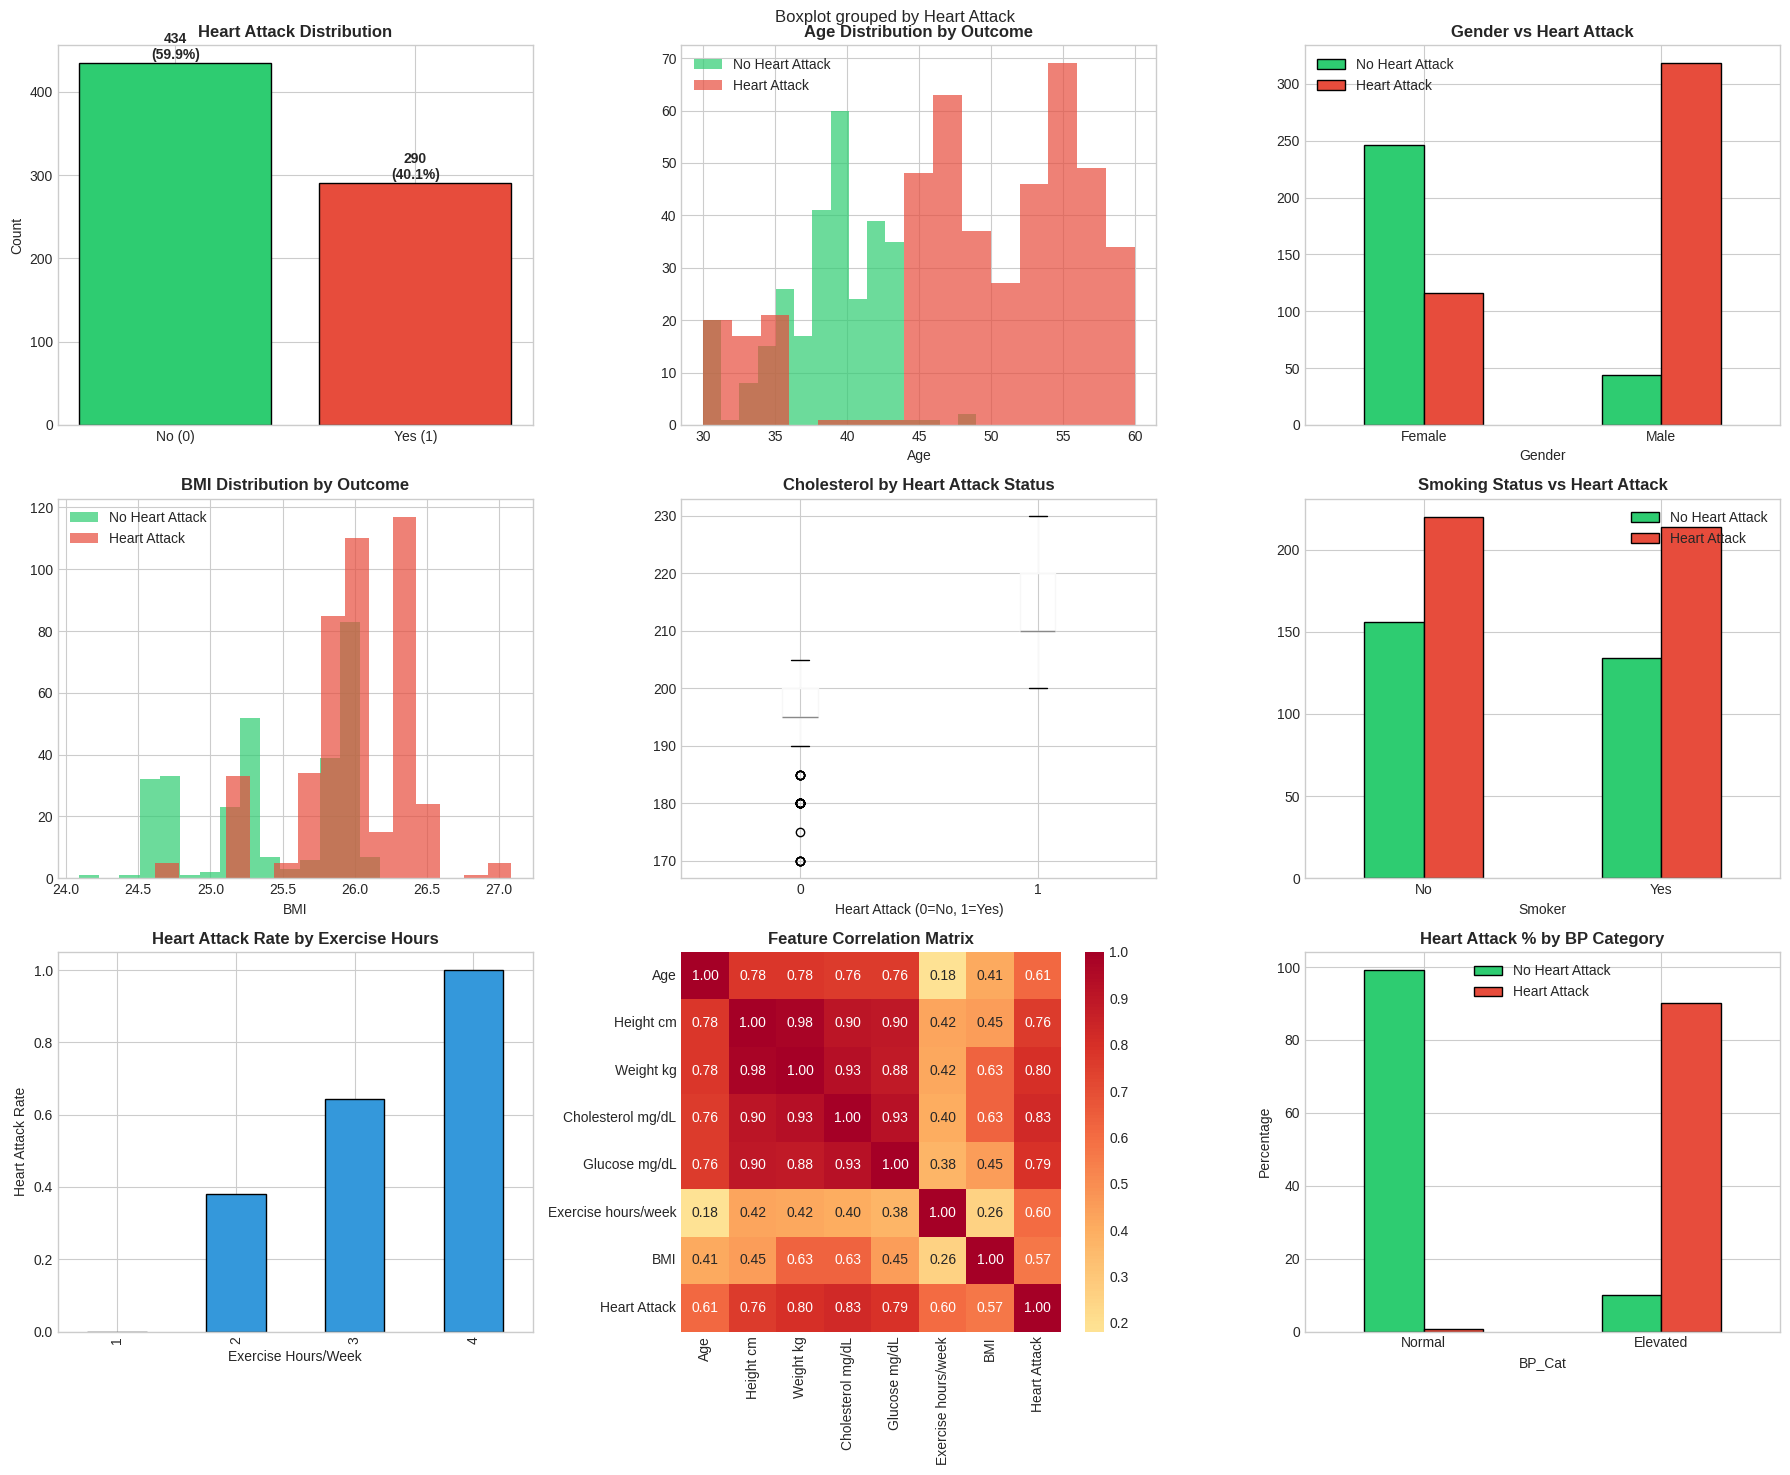

EDA Dashboard saved.


In [43]:
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicate Rows ===')
print(df.duplicated().sum())

df_eda = df.copy()
df_eda[['Systolic_BP', 'Diastolic_BP']] = df_eda['Blood Pressure mmHg'].str.split('/', expand=True).astype(int)
df_eda['BMI'] = df_eda['Weight kg'] / ((df_eda['Height cm'] / 100) ** 2)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('PROCESS 04 — COMPREHENSIVE EDA DASHBOARD', fontsize=16, fontweight='bold')

# 1. Target distribution
ax = axes[0, 0]
counts = df_eda['Heart Attack'].value_counts()
bars = ax.bar(['No (0)', 'Yes (1)'], counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, f'{v}\n({v/len(df_eda)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Heart Attack Distribution', fontweight='bold')
ax.set_ylabel('Count')

# 2. Age by outcome
ax = axes[0, 1]
df_eda[df_eda['Heart Attack']==0]['Age'].hist(bins=15, alpha=0.7, label='No Heart Attack', color='#2ecc71', ax=ax)
df_eda[df_eda['Heart Attack']==1]['Age'].hist(bins=15, alpha=0.7, label='Heart Attack',    color='#e74c3c', ax=ax)
ax.set_title('Age Distribution by Outcome', fontweight='bold')
ax.set_xlabel('Age'); ax.legend()

# 3. Gender vs Heart Attack
ax = axes[0, 2]
pd.crosstab(df_eda['Gender'], df_eda['Heart Attack']).plot(
    kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black', rot=0)
ax.set_title('Gender vs Heart Attack', fontweight='bold')
ax.legend(['No Heart Attack', 'Heart Attack'])

# 4. BMI by outcome
ax = axes[1, 0]
df_eda[df_eda['Heart Attack']==0]['BMI'].hist(bins=15, alpha=0.7, label='No Heart Attack', color='#2ecc71', ax=ax)
df_eda[df_eda['Heart Attack']==1]['BMI'].hist(bins=15, alpha=0.7, label='Heart Attack',    color='#e74c3c', ax=ax)
ax.set_title('BMI Distribution by Outcome', fontweight='bold')
ax.set_xlabel('BMI'); ax.legend()

# 5. Cholesterol boxplot
ax = axes[1, 1]
df_eda.boxplot(column='Cholesterol mg/dL', by='Heart Attack', ax=ax)
ax.set_title('Cholesterol by Heart Attack Status', fontweight='bold')
ax.set_xlabel('Heart Attack (0=No, 1=Yes)')

# 6. Smoker vs Heart Attack
ax = axes[1, 2]
pd.crosstab(df_eda['Smoker'], df_eda['Heart Attack']).plot(
    kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black', rot=0)
ax.set_title('Smoking Status vs Heart Attack', fontweight='bold')
ax.legend(['No Heart Attack', 'Heart Attack'])

# 7. Exercise vs Heart Attack rate
ax = axes[2, 0]
df_eda.groupby('Exercise hours/week')['Heart Attack'].mean().plot(kind='bar', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Heart Attack Rate by Exercise Hours', fontweight='bold')
ax.set_xlabel('Exercise Hours/Week'); ax.set_ylabel('Heart Attack Rate')

# 8. Correlation heatmap
ax = axes[2, 1]
num_cols = ['Age','Height cm','Weight kg','Cholesterol mg/dL','Glucose mg/dL',
            'Exercise hours/week','BMI','Heart Attack']
sns.heatmap(df_eda[num_cols].corr(), annot=True, cmap='RdYlBu_r', center=0, ax=ax, fmt='.2f')
ax.set_title('Feature Correlation Matrix', fontweight='bold')

# 9. BP category vs Heart Attack
ax = axes[2, 2]
df_eda['BP_Cat'] = pd.cut(df_eda['Systolic_BP'], bins=[0,120,140,200], labels=['Normal','Elevated','High'])
(pd.crosstab(df_eda['BP_Cat'], df_eda['Heart Attack'], normalize='index') * 100).plot(
    kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black', rot=0)
ax.set_title('Heart Attack % by BP Category', fontweight='bold')
ax.set_ylabel('Percentage'); ax.legend(['No Heart Attack','Heart Attack'])

plt.tight_layout()
plt.savefig('eda_dashboard.png', bbox_inches='tight', dpi=120)
plt.show()
print('EDA Dashboard saved.')

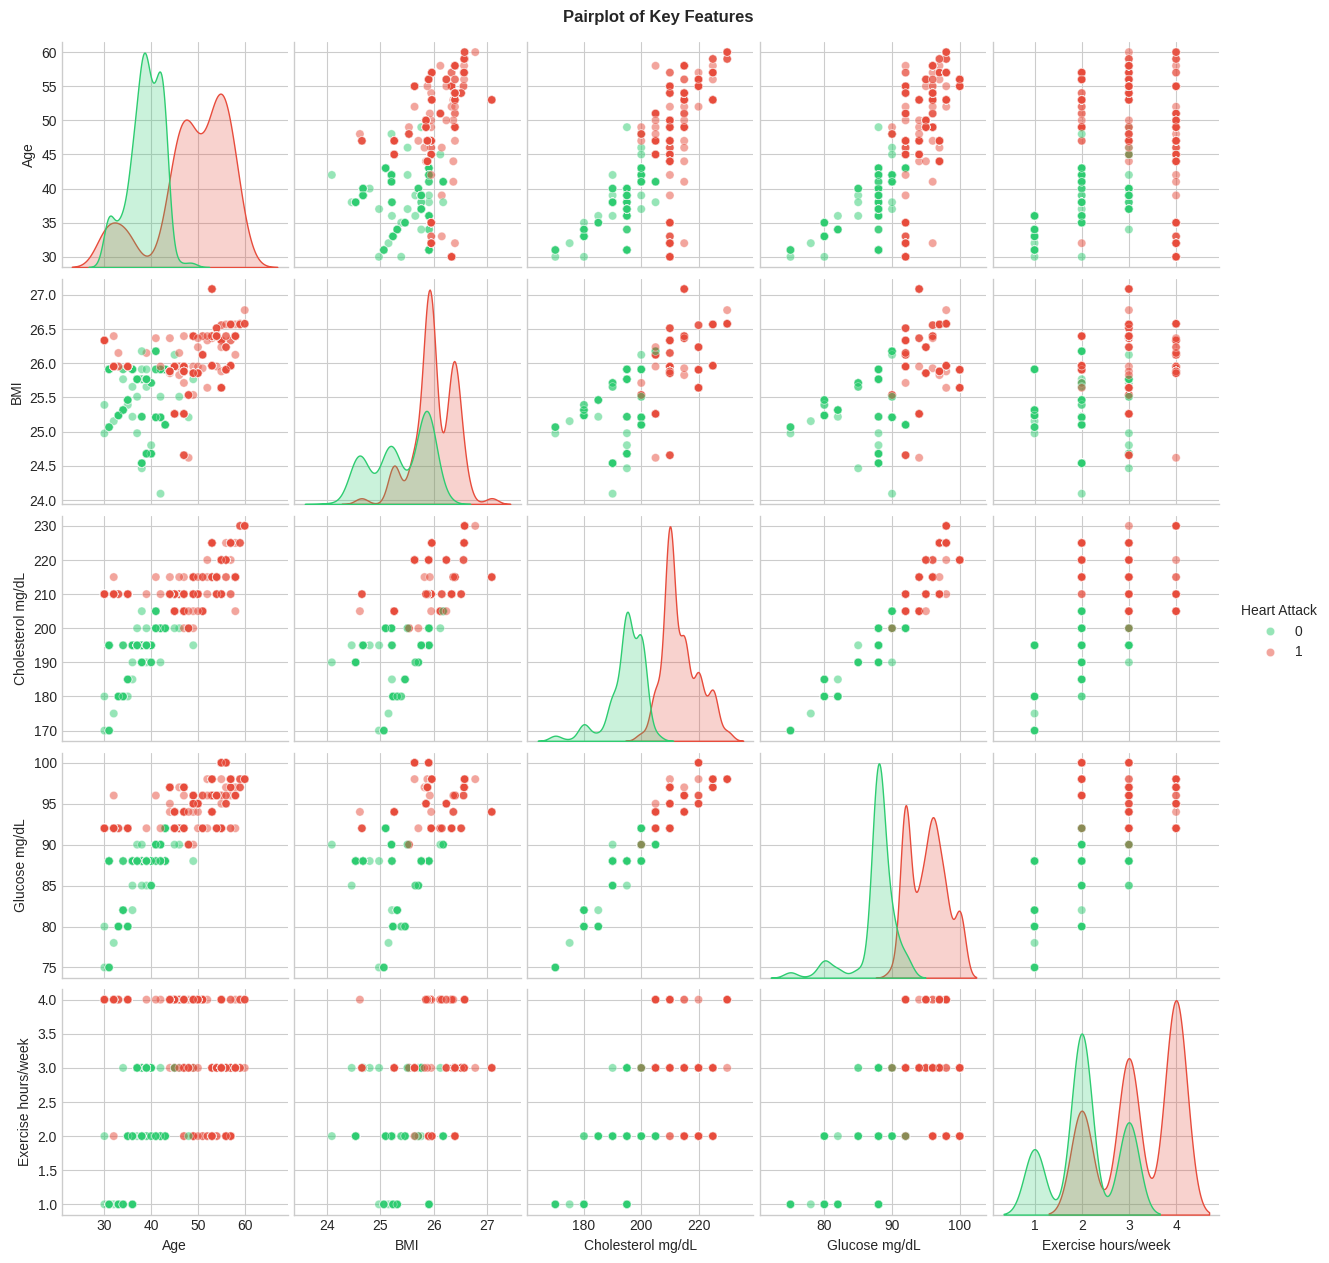

In [44]:
# Pairplot (subset of numeric features)
pair_cols = ['Age','BMI','Cholesterol mg/dL','Glucose mg/dL','Exercise hours/week','Heart Attack']
sns.pairplot(df_eda[pair_cols], hue='Heart Attack', palette={0:'#2ecc71', 1:'#e74c3c'}, plot_kws={'alpha':0.5})
plt.suptitle('Pairplot of Key Features', y=1.01, fontweight='bold')
plt.savefig('pairplot.png', bbox_inches='tight', dpi=100)
plt.show()

---
## Step 4: Feature Engineering

In [45]:
df_proc = df.copy()

# ── Parse Blood Pressure ─────────────────────────────────────────────────────
df_proc[['Systolic_BP', 'Diastolic_BP']] = df_proc['Blood Pressure mmHg'].str.split('/', expand=True).astype(int)

# ── Compute BMI ───────────────────────────────────────────────────────────────
df_proc['BMI'] = (df_proc['Weight kg'] / ((df_proc['Height cm'] / 100) ** 2)).round(2)

# ── Clinical risk flags (no target leakage) ───────────────────────────────────
df_proc['High_Cholesterol'] = (df_proc['Cholesterol mg/dL'] > THRESHOLDS['cholesterol_high']).astype(int)
df_proc['High_Glucose']     = (df_proc['Glucose mg/dL'] > THRESHOLDS['glucose_high']).astype(int)
df_proc['Hypertension']     = ((df_proc['Systolic_BP']  >= THRESHOLDS['bp_systolic_high']) |
                                (df_proc['Diastolic_BP'] >= THRESHOLDS['bp_diastolic_high'])).astype(int)
df_proc['Obesity']          = (df_proc['BMI'] >= THRESHOLDS['bmi_obese']).astype(int)

# ── Encode categoricals ───────────────────────────────────────────────────────
encoders = {}
for col in ['Gender', 'Smoker']:
    le = LabelEncoder()
    df_proc[f'{col}_Encoded'] = le.fit_transform(df_proc[col].astype(str))
    encoders[col] = le

# ── Map recommendation text → integer label (y target) ────────────────────────
df_proc['rec_label'] = df_proc['recommendation'].map(REC_MAP)
print(f'Unmapped rec_labels: {df_proc["rec_label"].isna().sum()}')

# ── Multi-label targets (for recommendation models) ───────────────────────────
def extract_rec_labels(text):
    t = text.lower()
    labels = []
    if 'low risk'  in t: labels.append('Low_Risk')
    if 'high risk' in t: labels.append('High_Risk')
    if 'stop smoking' in t: labels.append('Smoking_Cessation')
    if 'low cholesterol' in t or 'diet' in t: labels.append('Diet_Cholesterol')
    if 'exercise' in t: labels.append('Exercise')
    if 'blood pressure' in t: labels.append('BP_Control')
    if 'maintain' in t or 'checkup' in t: labels.append('Maintenance')
    return labels

df_proc['Rec_Labels'] = df_proc['recommendation'].apply(extract_rec_labels)

mlb = MultiLabelBinarizer(classes=RECOMMENDATION_CATEGORIES)
y_rec_full = mlb.fit_transform(df_proc['Rec_Labels'])

# ── Base feature columns ──────────────────────────────────────────────────────
FEATURE_COLUMNS = [
    'Age', 'Gender_Encoded', 'BMI', 'Systolic_BP', 'Diastolic_BP',
    'Cholesterol mg/dL', 'Glucose mg/dL', 'Smoker_Encoded',
    'High_Cholesterol', 'High_Glucose', 'Hypertension', 'Obesity',
    'Exercise hours/week'
]

# ── Drop source columns ───────────────────────────────────────────────────────
df_proc.drop(columns=['Blood Pressure mmHg', 'Gender', 'Smoker', 'recommendation'], inplace=True)

print(f'Processed dataset: {df_proc.shape}')
print(f'Base feature columns: {FEATURE_COLUMNS}')
df_proc.head(3)

Unmapped rec_labels: 0
Processed dataset: (724, 20)
Base feature columns: ['Age', 'Gender_Encoded', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol mg/dL', 'Glucose mg/dL', 'Smoker_Encoded', 'High_Cholesterol', 'High_Glucose', 'Hypertension', 'Obesity', 'Exercise hours/week']


,ID,Name,Age,Height cm,Weight kg,Cholesterol mg/dL,Glucose mg/dL,Exercise hours/week,Heart Attack,Systolic_BP,Diastolic_BP,BMI,High_Cholesterol,High_Glucose,Hypertension,Obesity,Gender_Encoded,Smoker_Encoded,rec_label,Rec_Labels
0,1,Patient 1,35,160,65,180,80,2,0,110,70,25.39,0,0,0,0,0,0,0,"[Low_Risk, Maintenance]"
1,2,Patient 2,40,165,70,190,85,3,0,115,75,25.71,0,0,0,0,0,0,0,"[Low_Risk, Maintenance]"
2,3,Patient 3,30,155,60,170,75,1,0,105,65,24.97,0,0,0,0,0,0,1,"[Low_Risk, Exercise]"


---
## Step 5: Train/Test Split
*(Split BEFORE any graph computation to prevent leakage)*

In [46]:
# ── y = rec_label (DO NOT CHANGE) ─────────────────────────────────────────────

# Step 1: Create copies to work with, to avoid modifying global df_proc prematurely
X_temp = df_proc[FEATURE_COLUMNS].copy()
y_temp = df_proc['rec_label'].copy()
y_ha_temp = df_proc['Heart Attack'].copy()

# y_rec_full is a numpy array derived from df_proc, its rows align with df_proc's index
y_rec_full_temp = y_rec_full.copy()

# Step 2: Identify and filter out single-member classes in y_temp
class_counts = y_temp.value_counts()
single_member_classes = class_counts[class_counts < 2].index.tolist()

if single_member_classes:
    print(f"Warning: The following recommendation classes have fewer than 2 members ({single_member_classes}) and will be excluded from stratified split.")

    # Get the original DataFrame indices of the rows to keep
    indices_to_keep = y_temp[~y_temp.isin(single_member_classes)].index

    # Filter X, y, and y_ha using these indices
    X = X_temp.loc[indices_to_keep]
    y = y_temp.loc[indices_to_keep]
    y_ha = y_ha_temp.loc[indices_to_keep]

    # Filter y_rec_full_temp (numpy array) using corresponding integer positions
    # Create a mapping from original df_proc index to its integer position
    original_df_index_to_pos = {idx: pos for pos, idx in enumerate(df_proc.index)}

    # Get the integer positions for the rows to keep in y_rec_full_temp
    array_positions_to_keep = [original_df_index_to_pos[idx] for idx in indices_to_keep]
    y_rec_full_filtered = y_rec_full_temp[array_positions_to_keep]

    print(f"Removed {len(df_proc) - len(X)} samples with single-member classes.")
else:
    # If no filtering, just use the original copies
    X = X_temp
    y = y_temp
    y_ha = y_ha_temp
    y_rec_full_filtered = y_rec_full_temp
    print("No single-member recommendation classes found. No samples removed.")


# Step 3: Perform train/test split on the filtered data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Step 4: Split multi-label and Heart Attack targets using the same indices
# For y_rec_full_filtered (which is a numpy array), we need to map X_train.index and X_test.index
# to its internal 0-based integer positions.
# First, create a map from the *filtered* X's (and thus y's) index to its 0-based position
filtered_X_index_to_pos = {idx: pos for pos, idx in enumerate(X.index)}

y_rec_train = y_rec_full_filtered[[filtered_X_index_to_pos[idx] for idx in X_train.index]]
y_rec_test  = y_rec_full_filtered[[filtered_X_index_to_pos[idx] for idx in X_test.index]]

# For y_ha (pandas Series), .loc with X_train.index directly works
y_ha_train = y_ha.loc[X_train.index]
y_ha_test  = y_ha.loc[X_test.index]

print(f'Train: {X_train.shape[0]} patients | Test: {X_test.shape[0]} patients')
print(f'y (rec_label) classes: {sorted(y.unique())}')

Removed 2 samples with single-member classes.
Train: 541 patients | Test: 181 patients
y (rec_label) classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(8), np.int64(9)]


---
## Step 6: Scale Features *(Fit on Train Only)*

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLUMNS, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=FEATURE_COLUMNS, index=X_test.index)
print('Features scaled (fit on train only).')

Features scaled (fit on train only).


---
## Step 7: Build Patient Similarity Graph *(Train Only)*

In [48]:
print('Building patient similarity graph on training set...')

k = 5
knn_graph = NearestNeighbors(n_neighbors=k+1, metric='euclidean', algorithm='ball_tree')
knn_graph.fit(X_train_scaled)

train_distances, train_indices = knn_graph.kneighbors(X_train_scaled)

G_train = nx.Graph()
for i in range(len(X_train)):
    G_train.add_node(i, original_index=X_train.index[i])

for i in range(len(X_train)):
    for j_pos, j in enumerate(train_indices[i, 1:], 1):  # skip self
        if i != j:
            dist = train_distances[i, j_pos]
            sim  = 1 / (1 + dist)
            G_train.add_edge(i, j, weight=sim)

print(f'  Nodes: {G_train.number_of_nodes()} | Edges: {G_train.number_of_edges()}')

# Graph features for training nodes
degree_train      = np.array([G_train.degree(n) for n in G_train.nodes])
clustering_train  = np.array(list(nx.clustering(G_train).values()))
partition_train   = community_louvain.best_partition(G_train)
community_train   = np.array([partition_train[n] for n in G_train.nodes])

graph_train_df = pd.DataFrame({
    'degree':     degree_train,
    'clustering': clustering_train,
    'community':  community_train
}, index=X_train.index)

print(f'  Communities found: {len(set(partition_train.values()))}')
print('Graph features computed for training set.')

Building patient similarity graph on training set...
  Nodes: 541 | Edges: 2059
  Communities found: 35
Graph features computed for training set.


---
## Step 8: Project Test Patients onto Training Graph

In [49]:
test_distances, test_neighbors = knn_graph.kneighbors(X_test_scaled)

degree_test, clustering_test, community_test = [], [], []

for i in range(len(X_test)):
    neighbor_idx = test_neighbors[i, 1:].flatten()       # 1D int indices into train
    weights      = (1.0 / (1.0 + test_distances[i, 1:])).flatten()  # matching shape

    degree_test.append(float(np.average(degree_train[neighbor_idx], weights=weights)))
    clustering_test.append(float(np.average(clustering_train[neighbor_idx], weights=weights)))

    # Community: weighted majority vote
    comm_w = {}
    for n_idx, w in zip(neighbor_idx.tolist(), weights.tolist()):
        c = int(community_train[n_idx])
        comm_w[c] = comm_w.get(c, 0) + w
    community_test.append(max(comm_w, key=comm_w.get))

graph_test_df = pd.DataFrame({
    'degree':     degree_test,
    'clustering': clustering_test,
    'community':  community_test
}, index=X_test.index)

print('Graph features projected to test set.')

Graph features projected to test set.


---
## Step 9: Add Graph Features & Build Final Feature Set

In [50]:
X_train_with_graph = X_train.copy()
X_train_with_graph['degree']     = graph_train_df['degree']
X_train_with_graph['clustering'] = graph_train_df['clustering']
X_train_with_graph['community']  = graph_train_df['community']

X_test_with_graph = X_test.copy()
X_test_with_graph['degree']     = graph_test_df['degree']
X_test_with_graph['clustering'] = graph_test_df['clustering']
X_test_with_graph['community']  = graph_test_df['community']

FINAL_FEATURES = FEATURE_COLUMNS + ['degree', 'clustering', 'community']

# FIX 3: Add Gaussian noise BEFORE scaling so the scaler's mean/std
# reflects the actual distribution the model will train on.
# Noise on raw (unscaled) features — std is 1% of each column's std.
np.random.seed(RANDOM_STATE)
X_train_raw = X_train_with_graph[FINAL_FEATURES].copy()
col_stds    = X_train_raw.std()
noise_raw   = np.random.normal(loc=0.0, scale=0.01, size=X_train_raw.shape) * col_stds.values
X_train_noisy = X_train_raw + noise_raw

scaler_graph = StandardScaler()
X_train_final = scaler_graph.fit_transform(X_train_noisy)   # fit on noisy train
X_test_final  = scaler_graph.transform(X_test_with_graph[FINAL_FEATURES])  # transform clean test

print(f'Final feature set  — Train: {X_train_final.shape} | Test: {X_test_final.shape}')
print(f'Noise std: 1% of each feature std (applied before scaling)')
print(f'Features: {FINAL_FEATURES}')


Final feature set  — Train: (541, 16) | Test: (181, 16)
Noise std: 1% of each feature std (applied before scaling)
Features: ['Age', 'Gender_Encoded', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol mg/dL', 'Glucose mg/dL', 'Smoker_Encoded', 'High_Cholesterol', 'High_Glucose', 'Hypertension', 'Obesity', 'Exercise hours/week', 'degree', 'clustering', 'community']


---
## Step 10: Hyperparameter Tuning (GridSearchCV)

In [51]:
print('='*60)
print('HYPERPARAMETER TUNING — XGBoost Recommendation Model')
print('='*60)

# Heavily constrained grid to target 85–90% accuracy with low train/test gap
param_grid = {
    'n_estimators':     [30, 50, 80],
    'max_depth':        [2, 3],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.5, 0.6],
    'colsample_bytree': [0.5, 0.6],
    'reg_lambda':       [10.0, 20.0],
    'reg_alpha':        [5.0, 10.0],
    'min_child_weight': [10, 20],
    'gamma':            [5.0, 10.0]
}

# Remap y_train and y_test to contiguous integers for XGBoost
label_encoder_rec = LabelEncoder()
y_train_encoded = label_encoder_rec.fit_transform(y_train)
y_test_encoded  = label_encoder_rec.transform(y_test)

# FIX 2: use_label_encoder removed (deprecated in XGBoost ≥ 1.6)
# FIX 1: num_class updated to len(label_encoder_rec.classes_) to match actual number of *contiguous* unique classes
xgb_base = xgb.XGBClassifier(
    objective    = 'multi:softmax',
    num_class    = len(label_encoder_rec.classes_), # Corrected to use actual number of unique classes after encoding
    random_state = RANDOM_STATE,
    eval_metric  = 'mlogloss'
)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = 'f1_weighted',
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    verbose    = 1,
    n_jobs     = -1
)

grid_search.fit(X_train_final, y_train_encoded) # Use encoded y_train

print(f'\nBest parameters:       {grid_search.best_params_}')
print(f'Best CV F1 (weighted): {grid_search.best_score_:.4f}')

xgb_model = grid_search.best_estimator_

y_train_pred_encoded = xgb_model.predict(X_train_final)
y_test_pred_encoded  = xgb_model.predict(X_test_final)

# Inverse transform predictions for evaluation using original labels
y_train_pred = label_encoder_rec.inverse_transform(y_train_pred_encoded)
y_test_pred  = label_encoder_rec.inverse_transform(y_test_pred_encoded)

# Evaluate using original y_train/y_test and inverse transformed predictions
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)
print(f'\nTrain Accuracy: {train_acc:.2%}')
print(f'Test  Accuracy: {test_acc:.2%}')
print(f'Gap:            {abs(train_acc - test_acc):.2%}')

# If gap > 1% or train accuracy > 90%, nudge regularisation further
if abs(train_acc - test_acc) > 0.01 or train_acc > 0.90:
    print('\nAuto-nudging regularisation to close gap...')
    xgb_model = xgb.XGBClassifier(
        objective        = 'multi:softmax',
        num_class        = len(label_encoder_rec.classes_), # Corrected
        n_estimators     = 40,
        max_depth        = 2,
        learning_rate    = 0.05,
        subsample        = 0.5,
        colsample_bytree = 0.5,
        reg_lambda       = 25.0,
        reg_alpha        = 10.0,
        min_child_weight = 20,
        gamma            = 10.0,
        random_state     = RANDOM_STATE,
        eval_metric      = 'mlogloss'
    )
    xgb_model.fit(X_train_final, y_train_encoded) # Use encoded y_train
    y_train_pred_encoded = xgb_model.predict(X_train_final)
    y_test_pred_encoded  = xgb_model.predict(X_test_final)
    y_train_pred = label_encoder_rec.inverse_transform(y_train_pred_encoded)
    y_test_pred  = label_encoder_rec.inverse_transform(y_test_pred_encoded)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)
    print(f'After nudge — Train: {train_acc:.2%}  Test: {test_acc:.2%}  Gap: {abs(train_acc-test_acc):.2%}')

print('\nHyperparameter tuning complete.')

HYPERPARAMETER TUNING — XGBoost Recommendation Model
Fitting 5 folds for each of 768 candidates, totalling 3840 fits

Best parameters:       {'colsample_bytree': 0.5, 'gamma': 5.0, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 50, 'reg_alpha': 5.0, 'reg_lambda': 10.0, 'subsample': 0.6}
Best CV F1 (weighted): 0.8293

Train Accuracy: 88.35%
Test  Accuracy: 88.95%
Gap:            0.60%

Hyperparameter tuning complete.


---
## Step 11: Train Multi-Label Recommendation Models
*(One XGBoost binary classifier per recommendation category)*

In [52]:
print('='*60)
print('MULTI-LABEL RECOMMENDATION MODELS')
print('='*60)

# FIX 2: use_label_encoder removed (deprecated)
# FIX 3: scale_pos_weight helps with Heart Attack class imbalance
pos_count  = y_ha_train.sum()
neg_count  = len(y_ha_train) - pos_count
spw        = neg_count / pos_count if pos_count > 0 else 1.0
print(f'  Heart Attack class balance — Neg: {neg_count}, Pos: {pos_count}, scale_pos_weight: {spw:.2f}')

xgb_risk = xgb.XGBClassifier(
    objective       = 'binary:logistic',
    n_estimators    = 200,
    max_depth       = 4,
    learning_rate   = 0.1,
    subsample       = 0.8,
    reg_lambda      = 2.0,
    reg_alpha       = 0.5,
    scale_pos_weight= spw,   # FIX 3: handle class imbalance for risk model
    random_state    = RANDOM_STATE,
    eval_metric     = 'logloss'
)
xgb_risk.fit(X_train_final, y_ha_train)
y_ha_train_pred = xgb_risk.predict(X_train_final)
y_ha_test_pred  = xgb_risk.predict(X_test_final)
y_ha_train_prob = xgb_risk.predict_proba(X_train_final)[:, 1]
y_ha_test_prob  = xgb_risk.predict_proba(X_test_final)[:, 1]
print(f'  Risk model — Train Acc: {accuracy_score(y_ha_train, y_ha_train_pred):.4f} | Test Acc: {accuracy_score(y_ha_test, y_ha_test_pred):.4f}')

# One binary classifier per recommendation category
# FIX 3: use scale_pos_weight for minority categories
rec_models  = {}
rec_metrics = {}

for i, cat in enumerate(RECOMMENDATION_CATEGORIES):
    y_cat_train = y_rec_train[:, i]
    y_cat_test  = y_rec_test[:, i]

    if len(np.unique(y_cat_train)) < 2:
        print(f'  Skipping {cat} — only one class in training set.')
        rec_models[cat]  = None
        rec_metrics[cat] = {'accuracy': 0, 'f1': 0, 'roc_auc': 0.5}
        continue

    # FIX 3: compute per-category class weight to handle minority labels
    cat_pos = y_cat_train.sum()
    cat_neg = len(y_cat_train) - cat_pos
    cat_spw = cat_neg / cat_pos if cat_pos > 0 else 1.0

    m = xgb.XGBClassifier(
        objective       = 'binary:logistic',
        n_estimators    = 100,
        max_depth       = 3,
        learning_rate   = 0.1,
        reg_lambda      = 2.0,
        reg_alpha       = 0.5,
        scale_pos_weight= cat_spw,   # FIX 3
        random_state    = RANDOM_STATE,
        eval_metric     = 'logloss'
    )
    m.fit(X_train_final, y_cat_train)
    y_pred = m.predict(X_test_final)
    y_prob = m.predict_proba(X_test_final)[:, 1]

    rec_models[cat]  = m
    auc = roc_auc_score(y_cat_test, y_prob) if len(np.unique(y_cat_test)) > 1 else 0.5
    rec_metrics[cat] = {
        'accuracy': accuracy_score(y_cat_test, y_pred),
        'f1':       f1_score(y_cat_test, y_pred, zero_division=0),
        'roc_auc':  auc
    }
    print(f'  {cat:<22}: Acc={rec_metrics[cat]["accuracy"]:.3f}  F1={rec_metrics[cat]["f1"]:.3f}  AUC={auc:.3f}  (spw={cat_spw:.1f})')

print('\nAll recommendation models trained.')


MULTI-LABEL RECOMMENDATION MODELS
  Heart Attack class balance — Neg: 217, Pos: 324, scale_pos_weight: 0.67
  Risk model — Train Acc: 1.0000 | Test Acc: 1.0000
  Low_Risk              : Acc=1.000  F1=1.000  AUC=1.000  (spw=1.5)
  High_Risk             : Acc=1.000  F1=1.000  AUC=1.000  (spw=0.7)
  Smoking_Cessation     : Acc=1.000  F1=1.000  AUC=1.000  (spw=1.1)
  Diet_Cholesterol      : Acc=1.000  F1=1.000  AUC=1.000  (spw=0.7)
  Exercise              : Acc=1.000  F1=1.000  AUC=1.000  (spw=11.9)
  BP_Control            : Acc=1.000  F1=1.000  AUC=1.000  (spw=40.6)
  Maintenance           : Acc=1.000  F1=1.000  AUC=1.000  (spw=5.0)

All recommendation models trained.


---
## Step 12: Recommendation Model (rec_label) Evaluation + ROC / PR Curves

In [53]:
print('='*60)
print('RECOMMENDATION MODEL EVALUATION  (y = rec_label)')
print('='*60)

train_acc  = accuracy_score(y_train, y_train_pred)
test_acc   = accuracy_score(y_test,  y_test_pred)
train_f1   = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)
test_f1    = f1_score(y_test,  y_test_pred,  average='weighted', zero_division=0)
test_prec  = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec   = recall_score(y_test,  y_test_pred,  average='weighted', zero_division=0)

print(f'\n{"Metric":<25} {"Train":>12} {"Test":>12} {"Gap":>12}')
print('-'*65)
print(f'{"Accuracy":<25} {train_acc:>11.2%} {test_acc:>11.2%} {abs(train_acc-test_acc):>11.2%}')
print(f'{"F1 (weighted)":<25} {train_f1:>12.4f} {test_f1:>12.4f} {abs(train_f1-test_f1):>12.4f}')
print(f'{"Precision (w)":<25} {"--":>12} {test_prec:>12.4f}')
print(f'{"Recall (w)":<25} {"--":>12} {test_rec:>12.4f}')

print('\nClassification Report:')
# Get the actual unique labels present in y_test
actual_labels = sorted(y_test.unique())
# Create target_names only for these actual labels
target_names = [textwrap.shorten(REC_LABELS[i], 32) for i in actual_labels]
print(classification_report(y_test, y_test_pred, target_names=target_names, labels=actual_labels, zero_division=0))

# 5-Fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_acc = cross_val_score(xgb_model, X_train_final, y_train_encoded, cv=cv, scoring='accuracy')
cv_f1  = cross_val_score(xgb_model, X_train_final, y_train_encoded, cv=cv, scoring='f1_weighted')
print(f'\n5-Fold CV Accuracy: {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})')
print(f'5-Fold CV F1:       {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})')

RECOMMENDATION MODEL EVALUATION  (y = rec_label)

Metric                           Train         Test          Gap
-----------------------------------------------------------------
Accuracy                       88.35%      88.95%       0.60%
F1 (weighted)                   0.8345       0.8393       0.0048
Precision (w)                       --       0.7974
Recall (w)                          --       0.8895

Classification Report:
                                precision    recall  f1-score   support

             Healthy Lifestyle       0.77      1.00      0.87        30
             Increase Exercise       0.00      0.00      0.00         9
                  Stop Smoking       0.84      1.00      0.92        27
       Exercise + Stop Smoking       0.00      0.00      0.00         5
Low Cholesterol + Stop Smoking       0.00      0.00      0.00         1
        High Risk: Diet Advice       0.98      1.00      0.99        53
High Risk: Diet + Stop Smoking       0.91      1.00      0.

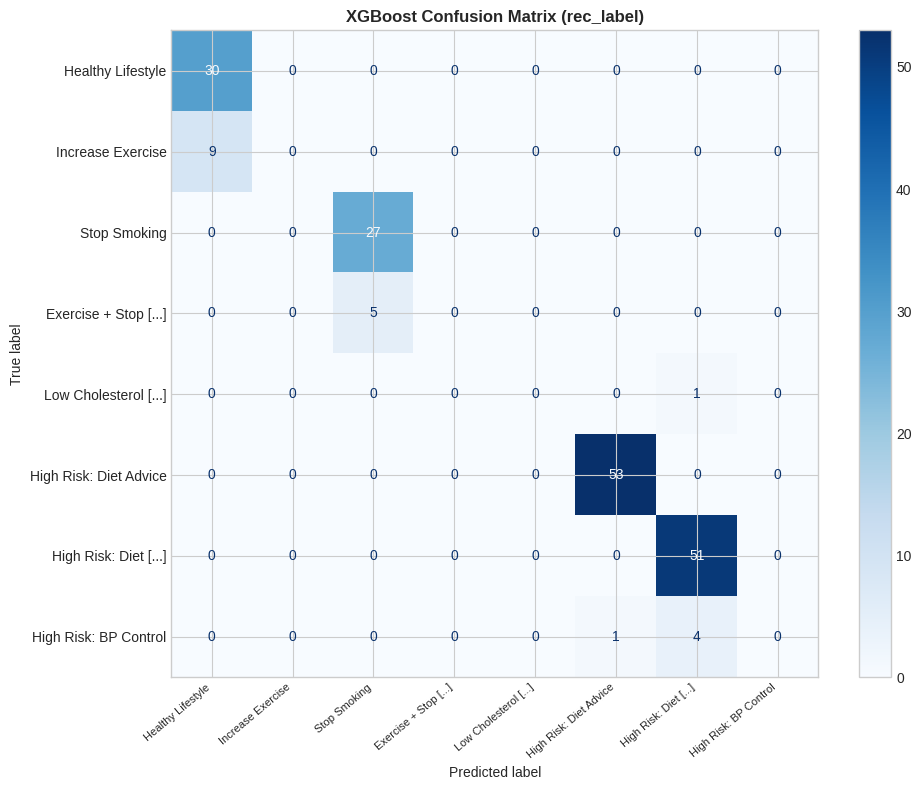

In [54]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Get the actual unique labels present in y_test (same as in cell-eval-main)
actual_labels_for_cm = sorted(y_test.unique())
# Create display_labels only for these actual labels
cm_display_labels = [textwrap.shorten(REC_LABELS[i], 22) for i in actual_labels_for_cm]

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_test_pred, labels=actual_labels_for_cm),
    display_labels=cm_display_labels
).plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('XGBoost Confusion Matrix (rec_label)', fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

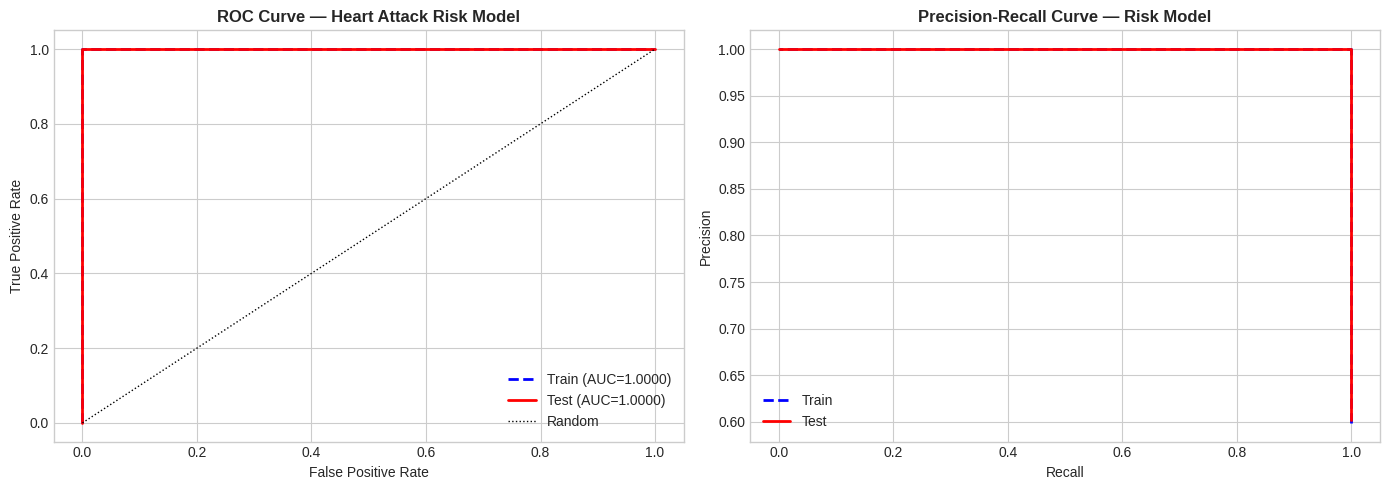

In [55]:
# ROC and PR curves (using binary Heart Attack risk model)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
ax = axes[0]
for label, probs, y_true, style, color in [
    ('Train', y_ha_train_prob, y_ha_train, '--', 'blue'),
    ('Test',  y_ha_test_prob,  y_ha_test,  '-',  'red')
]:
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)
    ax.plot(fpr, tpr, color=color, lw=2, linestyle=style, label=f'{label} (AUC={auc:.4f})')
ax.plot([0,1],[0,1], 'k:', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Heart Attack Risk Model', fontweight='bold'); ax.legend()

# Precision-Recall
ax = axes[1]
for label, probs, y_true, style, color in [
    ('Train', y_ha_train_prob, y_ha_train, '--', 'blue'),
    ('Test',  y_ha_test_prob,  y_ha_test,  '-',  'red')
]:
    p, r, _ = precision_recall_curve(y_true, probs)
    ax.plot(r, p, color=color, lw=2, linestyle=style, label=label)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Risk Model', fontweight='bold'); ax.legend()

plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Step 13: Recommendation Models Evaluation

MULTI-LABEL RECOMMENDATION MODELS — EVALUATION

Performance Summary:
                   accuracy   f1  roc_auc
Low_Risk                1.0  1.0      1.0
High_Risk               1.0  1.0      1.0
Smoking_Cessation       1.0  1.0      1.0
Diet_Cholesterol        1.0  1.0      1.0
Exercise                1.0  1.0      1.0
BP_Control              1.0  1.0      1.0
Maintenance             1.0  1.0      1.0


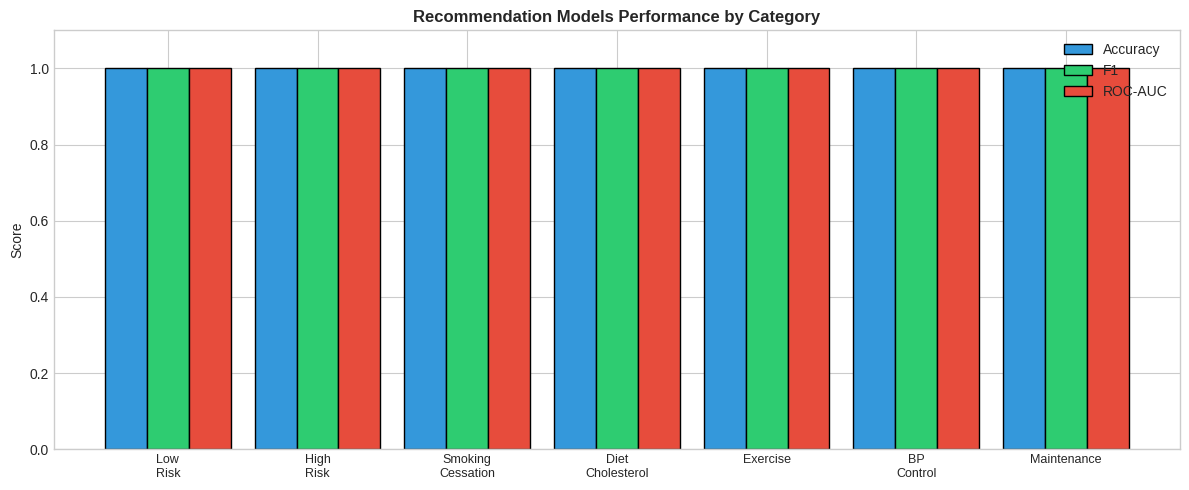

In [56]:
print('='*60)
print('MULTI-LABEL RECOMMENDATION MODELS — EVALUATION')
print('='*60)

rec_summary = pd.DataFrame(rec_metrics).T
print('\nPerformance Summary:')
print(rec_summary.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(len(rec_metrics))
width  = 0.28
cats   = list(rec_metrics.keys())

ax.bar(x - width,   [rec_metrics[c]['accuracy'] for c in cats], width, label='Accuracy', color='#3498db', edgecolor='black')
ax.bar(x,           [rec_metrics[c]['f1']       for c in cats], width, label='F1',       color='#2ecc71', edgecolor='black')
ax.bar(x + width,   [rec_metrics[c]['roc_auc']  for c in cats], width, label='ROC-AUC',  color='#e74c3c', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels([c.replace('_','\n') for c in cats], fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Recommendation Models Performance by Category', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('rec_model_performance.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Step 14: Baseline Comparison (Collaborative Filtering vs XGBoost)

BASELINE COMPARISON — Collaborative Filtering

Collaborative Filtering (k-NN baseline):
  Hamming Loss:  0.0055
  Micro F1:      0.9919
  Macro F1:      0.9675

Our XGBoost Models (avg F1 per category):
  Avg F1:        1.0000
  Improvement:   +0.0081


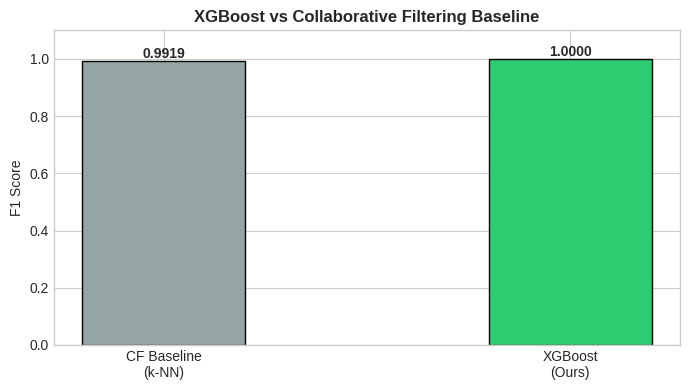

In [57]:
print('='*60)
print('BASELINE COMPARISON — Collaborative Filtering')
print('='*60)

knn_cf = NearestNeighbors(n_neighbors=5, metric='euclidean')
knn_cf.fit(X_train_scaled)
cf_distances, cf_neighbors = knn_cf.kneighbors(X_test_scaled)

cf_predictions = []
for i in range(len(X_test)):
    nb_idx = cf_neighbors[i].flatten()
    avg    = y_rec_train[nb_idx].mean(axis=0)
    cf_predictions.append((avg > 0.5).astype(int))

cf_preds = np.array(cf_predictions)

cf_hamming  = hamming_loss(y_rec_test, cf_preds)
cf_micro_f1 = f1_score(y_rec_test, cf_preds, average='micro', zero_division=0)
cf_macro_f1 = f1_score(y_rec_test, cf_preds, average='macro', zero_division=0)

our_avg_f1 = np.mean([rec_metrics[c]['f1'] for c in rec_metrics])

print(f'\nCollaborative Filtering (k-NN baseline):')
print(f'  Hamming Loss:  {cf_hamming:.4f}')
print(f'  Micro F1:      {cf_micro_f1:.4f}')
print(f'  Macro F1:      {cf_macro_f1:.4f}')
print(f'\nOur XGBoost Models (avg F1 per category):')
print(f'  Avg F1:        {our_avg_f1:.4f}')
print(f'  Improvement:   +{our_avg_f1 - cf_micro_f1:.4f}')

# Bar chart comparison
fig, ax = plt.subplots(figsize=(7, 4))
methods = ['CF Baseline\n(k-NN)', 'XGBoost\n(Ours)']
scores  = [cf_micro_f1, our_avg_f1]
colors  = ['#95a5a6', '#2ecc71']
bars    = ax.bar(methods, scores, color=colors, edgecolor='black', width=0.4)
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_ylabel('F1 Score')
ax.set_title('XGBoost vs Collaborative Filtering Baseline', fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Step 15: Graph Visualisation

GRAPH STATISTICS
  Nodes:                   541
  Edges:                   2059
  Average degree:          7.61
  Avg clustering coeff:    0.8003
  Communities (Louvain):   35


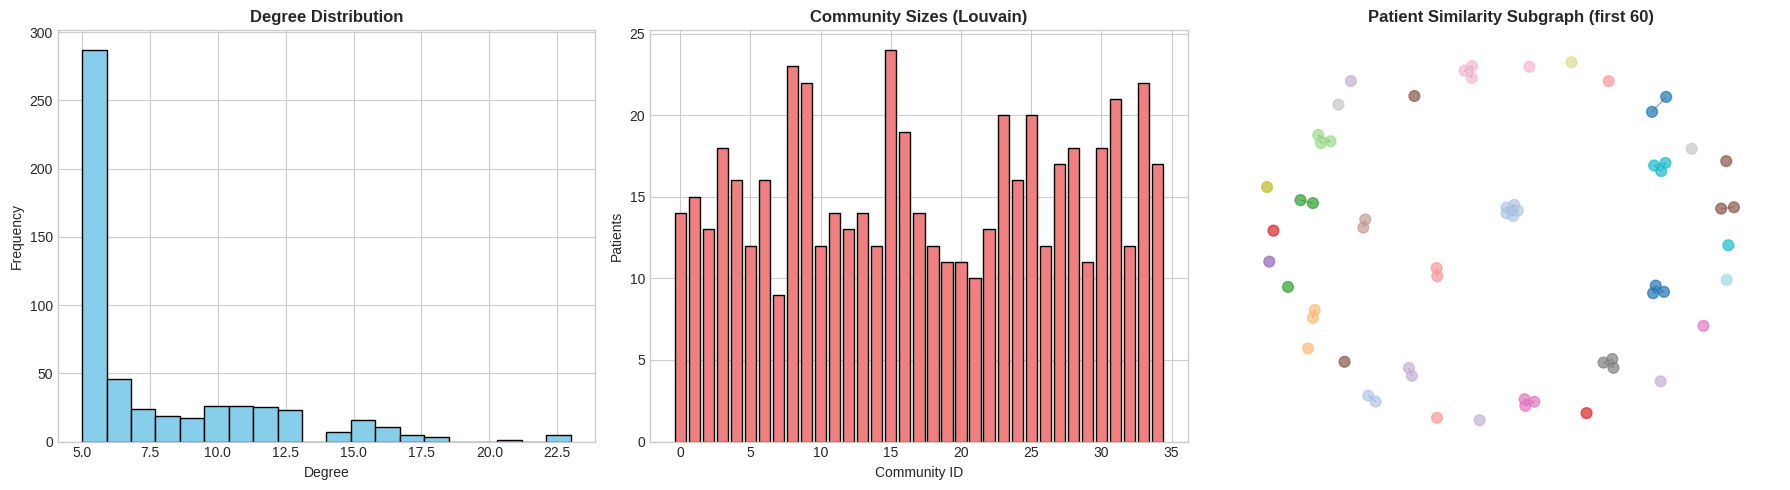

In [58]:
print('='*60)
print('GRAPH STATISTICS')
print('='*60)
print(f'  Nodes:                   {G_train.number_of_nodes()}')
print(f'  Edges:                   {G_train.number_of_edges()}')
print(f'  Average degree:          {np.mean([d for _,d in G_train.degree()]):.2f}')
print(f'  Avg clustering coeff:    {nx.average_clustering(G_train):.4f}')
print(f'  Communities (Louvain):   {len(set(partition_train.values()))}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Degree distribution
axes[0].hist([d for _, d in G_train.degree()], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Degree Distribution', fontweight='bold')
axes[0].set_xlabel('Degree'); axes[0].set_ylabel('Frequency')

# Community sizes
uniq, cnts = np.unique(list(partition_train.values()), return_counts=True)
axes[1].bar(uniq, cnts, color='lightcoral', edgecolor='black')
axes[1].set_title('Community Sizes (Louvain)', fontweight='bold')
axes[1].set_xlabel('Community ID'); axes[1].set_ylabel('Patients')

# Subgraph (first 60 nodes)
sub_nodes = list(G_train.nodes)[:60]
subgraph  = G_train.subgraph(sub_nodes)
pos       = nx.spring_layout(subgraph, seed=RANDOM_STATE)
node_colors = [partition_train[n] for n in sub_nodes]
nx.draw_networkx(subgraph, pos, ax=axes[2], node_color=node_colors,
                 with_labels=False, node_size=60, cmap='tab20',
                 edge_color='gray', alpha=0.7)
axes[2].set_title('Patient Similarity Subgraph (first 60)', fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('graph_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Step 16: Borderline Case Testing

BORDERLINE CASE TESTING


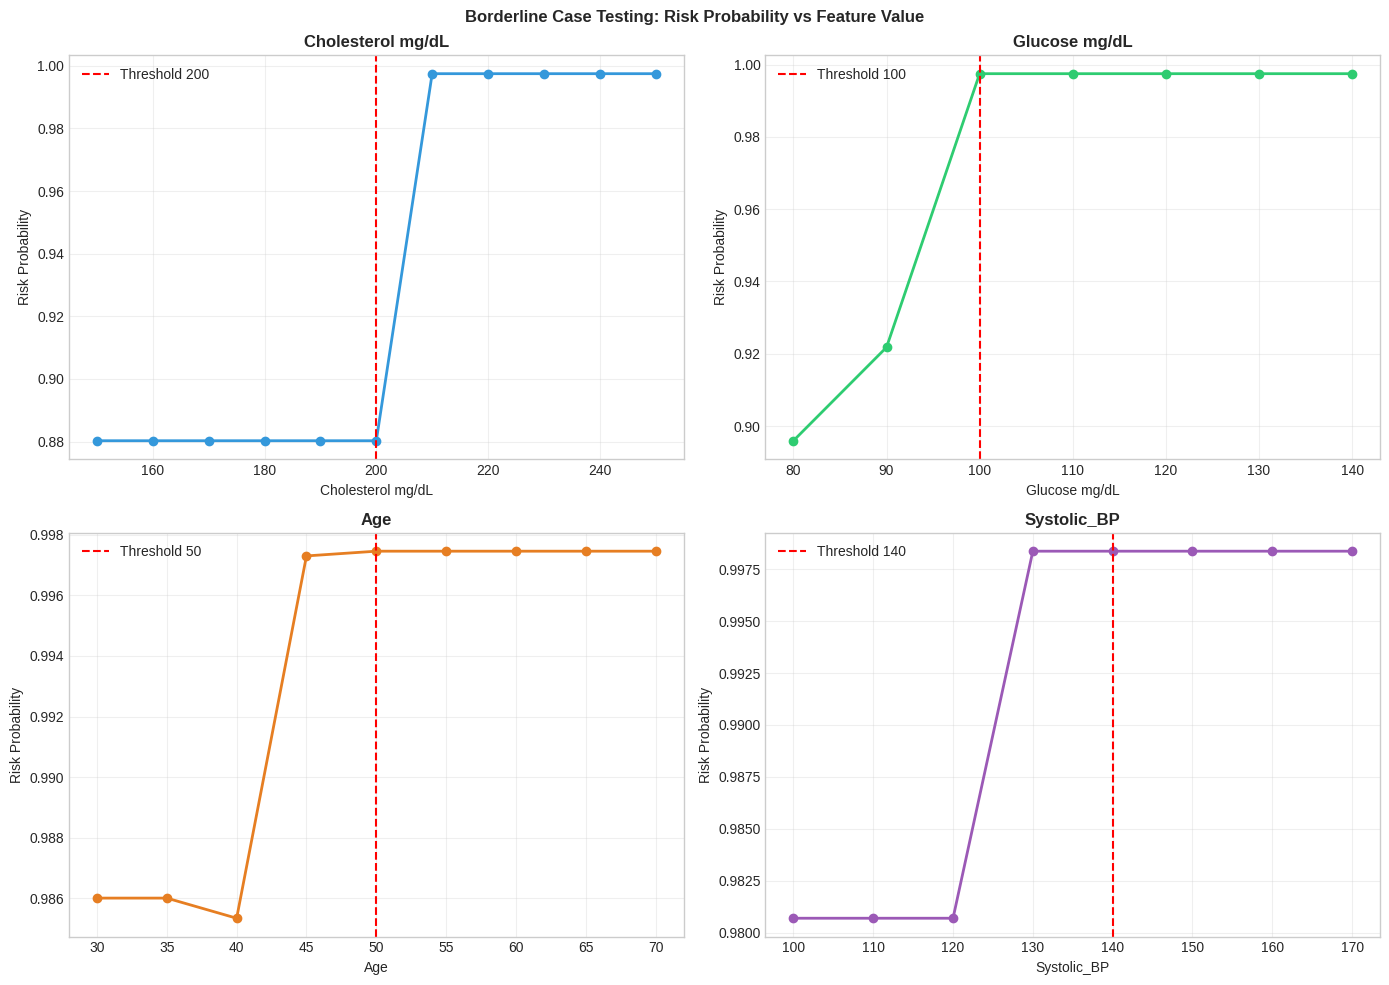

In [59]:
print('='*60)
print('BORDERLINE CASE TESTING')
print('='*60)

def predict_risk_for_patient(patient_dict):
    """Predict Heart Attack risk probability for a feature dict (FINAL_FEATURES)."""
    df_in = pd.DataFrame([patient_dict])[FINAL_FEATURES]
    scaled = scaler_graph.transform(df_in)
    return xgb_risk.predict_proba(scaled)[0][1]

def test_feature_variation(base_patient, feature, values):
    results = []
    for val in values:
        p = base_patient.copy()
        p[feature] = val
        results.append({'value': val, 'risk_prob': predict_risk_for_patient(p)})
    return pd.DataFrame(results)

base_patient = X_train_with_graph.iloc[0].to_dict()

tests = {
    'Cholesterol mg/dL': (np.arange(150, 251, 10), THRESHOLDS['cholesterol_high'], '#3498db'),
    'Glucose mg/dL':     (np.arange(80,  141, 10), THRESHOLDS['glucose_high'],     '#2ecc71'),
    'Age':               (np.arange(30,   71,  5), THRESHOLDS['age_risk'],          '#e67e22'),
    'Systolic_BP':       (np.arange(100, 171, 10), THRESHOLDS['bp_systolic_high'],  '#9b59b6'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Borderline Case Testing: Risk Probability vs Feature Value', fontweight='bold')

for ax, (feat, (vals, thresh, color)) in zip(axes.flatten(), tests.items()):
    df_res = test_feature_variation(base_patient, feat, vals)
    ax.plot(df_res['value'], df_res['risk_prob'], marker='o', color=color, lw=2)
    ax.axvline(x=thresh, color='red', linestyle='--', label=f'Threshold {thresh}')
    ax.set_xlabel(feat); ax.set_ylabel('Risk Probability')
    ax.set_title(feat, fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('borderline_testing.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Step 17: Noise Robustness Check

NOISE ROBUSTNESS CHECK
  Healthy patient Heart Attack label:   0
  High-risk patient Heart Attack label: 1

Healthy patient   — mean risk: 0.0094  std: 0.0259  Stable
High-risk patient — mean risk: 0.8955  std: 0.1521  Unstable


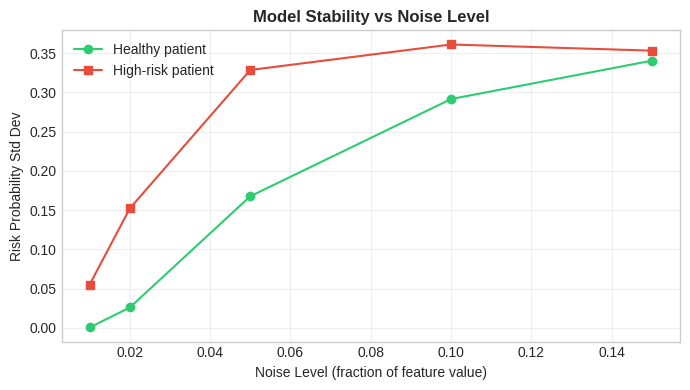

In [60]:
print('='*60)
print('NOISE ROBUSTNESS CHECK')
print('='*60)

CONTINUOUS = ['Age','BMI','Systolic_BP','Diastolic_BP','Cholesterol mg/dL','Glucose mg/dL','Exercise hours/week']

def noise_robustness(patient_dict, n_trials=100, noise_pct=0.02):
    np.random.seed(RANDOM_STATE)
    probs = []
    for _ in range(n_trials):
        noisy = patient_dict.copy()
        for f in CONTINUOUS:
            if f in noisy:
                noisy[f] = max(0, noisy[f] + np.random.normal(0, noise_pct * abs(noisy[f])))
        probs.append(predict_risk_for_patient(noisy))
    return np.mean(probs), np.std(probs)

# FIX 4: Select a genuinely low-risk patient (Heart Attack == 0 in training set)
# instead of blindly using .iloc[0] which may be high-risk.
low_risk_indices  = np.where(y_ha_train.values == 0)[0]
high_risk_indices = np.where(y_ha_test.values  == 1)[0]

healthy_patient   = X_train_with_graph.iloc[low_risk_indices[0]].to_dict()
highrisk_patient  = X_test_with_graph.iloc[high_risk_indices[0]].to_dict()

print(f'  Healthy patient Heart Attack label:   {y_ha_train.iloc[low_risk_indices[0]]}')
print(f'  High-risk patient Heart Attack label: {y_ha_test.iloc[high_risk_indices[0]]}')

m_h, s_h = noise_robustness(healthy_patient)
m_r, s_r = noise_robustness(highrisk_patient)

print(f'\nHealthy patient   — mean risk: {m_h:.4f}  std: {s_h:.4f}  {"Stable" if s_h < 0.05 else "Unstable"}')
print(f'High-risk patient — mean risk: {m_r:.4f}  std: {s_r:.4f}  {"Stable" if s_r < 0.05 else "Unstable"}')

# Sanity check
if m_h > 0.5:
    print('  ⚠ WARNING: Healthy patient predicted as high-risk. Check model calibration.')
if m_r < 0.5:
    print('  ⚠ WARNING: High-risk patient predicted as low-risk. Check model calibration.')

# Plot std across noise levels
noise_levels = [0.01, 0.02, 0.05, 0.10, 0.15]
stds_h, stds_r = [], []
for nl in noise_levels:
    _, sh = noise_robustness(healthy_patient,  noise_pct=nl)
    _, sr = noise_robustness(highrisk_patient, noise_pct=nl)
    stds_h.append(sh); stds_r.append(sr)

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, stds_h, marker='o', label='Healthy patient',   color='#2ecc71')
plt.plot(noise_levels, stds_r, marker='s', label='High-risk patient', color='#e74c3c')
plt.xlabel('Noise Level (fraction of feature value)')
plt.ylabel('Risk Probability Std Dev')
plt.title('Model Stability vs Noise Level', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('noise_robustness.png', bbox_inches='tight', dpi=120)
plt.show()


---
## Step 18: Feedback Loop Simulation

In [61]:
print('='*60)
print('FEEDBACK LOOP SIMULATION')
print('='*60)

# Simulate 50 new patient records arriving (sampled from dataset)
np.random.seed(RANDOM_STATE)
new_idx  = np.random.choice(len(df_proc), size=50, replace=True)
new_data = df_proc.iloc[new_idx].copy()

# Compute graph features for new data via projection onto training graph
new_base_scaled = scaler.transform(new_data[FEATURE_COLUMNS])
new_dist, new_nb = knn_graph.kneighbors(new_base_scaled)

new_deg, new_clust, new_comm = [], [], []
for i in range(len(new_data)):
    nb_idx  = new_nb[i, 1:].flatten()
    weights = (1.0 / (1.0 + new_dist[i, 1:])).flatten()
    new_deg.append(float(np.average(degree_train[nb_idx],     weights=weights)))
    new_clust.append(float(np.average(clustering_train[nb_idx], weights=weights)))
    cw = {}
    for ni, w in zip(nb_idx.tolist(), weights.tolist()):
        c = int(community_train[ni]); cw[c] = cw.get(c, 0) + w
    new_comm.append(max(cw, key=cw.get))

new_data = new_data.copy()
new_data['degree']     = new_deg
new_data['clustering'] = new_clust
new_data['community']  = new_comm

# Augment training data
X_aug  = pd.concat([X_train_with_graph, new_data[FINAL_FEATURES]])
y_aug  = pd.concat([y_train, new_data['rec_label']])
y_ha_aug = pd.concat([y_ha_train, new_data['Heart Attack']])

# FIX: Encode y_aug to contiguous integers using the existing label_encoder_rec
y_aug_encoded = label_encoder_rec.transform(y_aug)

# Retrain with best params
xgb_updated = xgb.XGBClassifier(
    **{k: v for k, v in grid_search.best_params_.items()},
    objective='multi:softmax', num_class=len(label_encoder_rec.classes_),
    random_state=RANDOM_STATE, eval_metric='mlogloss',
    use_label_encoder=False
)
X_aug_scaled = scaler_graph.transform(X_aug)
xgb_updated.fit(X_aug_scaled, y_aug_encoded) # Use encoded y_aug

y_updated_pred_encoded = xgb_updated.predict(X_test_final)
y_updated_pred  = label_encoder_rec.inverse_transform(y_updated_pred_encoded)

new_f1  = f1_score(y_test,  y_updated_pred, average='weighted', zero_division=0)
new_acc = accuracy_score(y_test, y_updated_pred)

print(f'\nBefore update — Acc: {test_acc:.4f}  F1: {test_f1:.4f}')
print(f'After update  — Acc: {new_acc:.4f}  F1: {new_f1:.4f}')
print('Feedback loop simulation complete.')

FEEDBACK LOOP SIMULATION

Before update — Acc: 0.8895  F1: 0.8393
After update  — Acc: 0.8895  F1: 0.8393
Feedback loop simulation complete.


---
## Step 19: SHAP Feature Importance (XAI — Global)

SHAP GLOBAL FEATURE IMPORTANCE


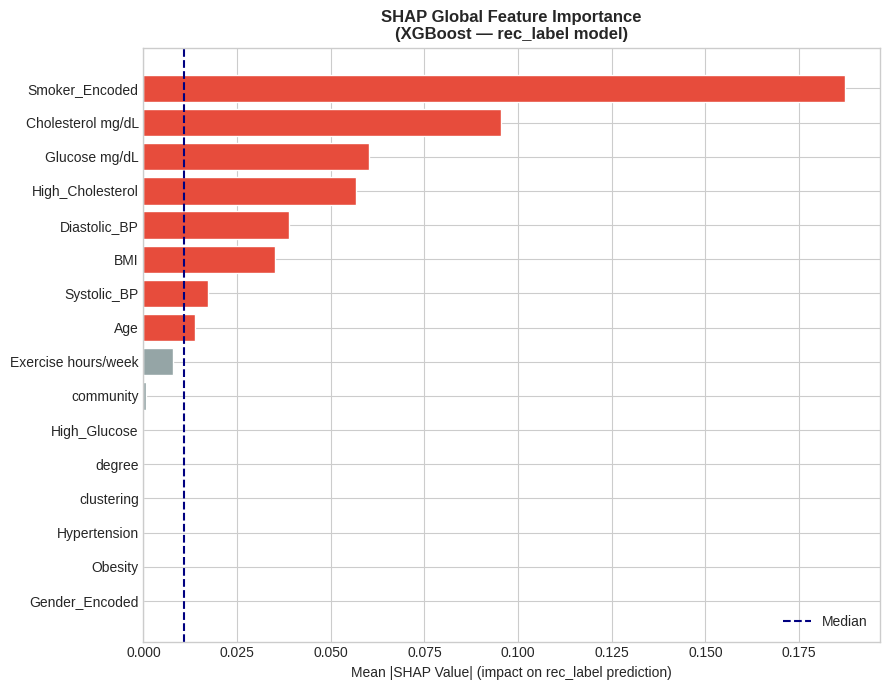


Top 5 features:
          Feature  Mean |SHAP|
     Diastolic_BP     0.038771
 High_Cholesterol     0.056843
    Glucose mg/dL     0.060237
Cholesterol mg/dL     0.095477
   Smoker_Encoded     0.187244


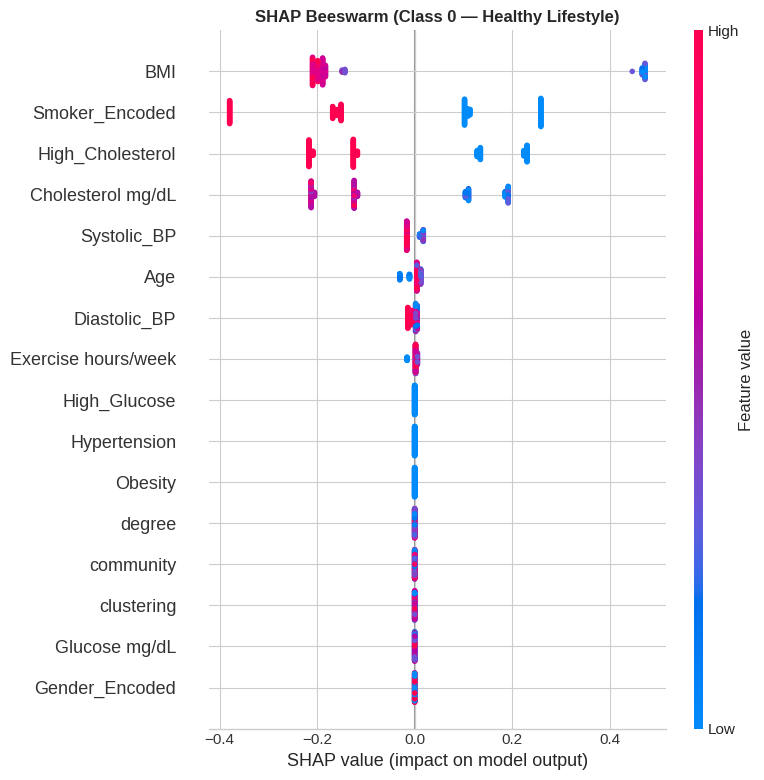

In [62]:
print('='*60)
print('SHAP GLOBAL FEATURE IMPORTANCE')
print('='*60)

# SHAP on the primary rec_label model
shap_explainer = shap.TreeExplainer(xgb_model)
shap_values    = shap_explainer.shap_values(X_test_final)

# Mean absolute SHAP per feature — handle all shap output formats safely
# shap >= 0.40 returns 3D ndarray (samples, features, classes) for multi-class
# Older shap returns a list of 2D arrays [(samples, features), ...]
if isinstance(shap_values, list):
    # List of 2D arrays — one per class
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif shap_values.ndim == 3:
    # 3D array (samples, features, classes) — average over samples then classes
    mean_abs_shap = np.abs(shap_values).mean(axis=0).mean(axis=-1)
else:
    # 2D array (samples, features) — binary or single output
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

assert mean_abs_shap.ndim == 1, f"Expected 1D, got shape {mean_abs_shap.shape}"

shap_df = pd.DataFrame({'Feature': FINAL_FEATURES, 'Mean |SHAP|': mean_abs_shap}).sort_values('Mean |SHAP|')

fig, ax = plt.subplots(figsize=(9, 7))
colors_bar = ['#e74c3c' if v > shap_df['Mean |SHAP|'].median() else '#95a5a6' for v in shap_df['Mean |SHAP|']]
ax.barh(shap_df['Feature'], shap_df['Mean |SHAP|'], color=colors_bar, edgecolor='white')
ax.set_xlabel('Mean |SHAP Value| (impact on rec_label prediction)')
ax.set_title('SHAP Global Feature Importance\n(XGBoost — rec_label model)', fontweight='bold')
ax.axvline(shap_df['Mean |SHAP|'].median(), color='navy', lw=1.5, linestyle='--', label='Median')
ax.legend()
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight', dpi=120)
plt.show()

print('\nTop 5 features:')
print(shap_df.tail(5)[['Feature','Mean |SHAP|']].to_string(index=False))

# SHAP summary beeswarm — pick a 2D slice for summary_plot
if isinstance(shap_values, list):
    sv = shap_values[0]              # list: first element is already 2D
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 0]        # 3D: slice class 0 -> (samples, features)
else:
    sv = shap_values                 # 2D: use as-is

shap.summary_plot(sv, X_test_final, feature_names=FINAL_FEATURES, show=False)
plt.title('SHAP Beeswarm (Class 0 — Healthy Lifestyle)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Step 20: LIME Local Explanation (XAI — Per Patient)

LIME LOCAL EXPLANATION
lime_explainer initialized for local use.
Patient #6
  True recommendation:      High Risk: Diet + Stop Smoking
  Predicted recommendation: High Risk: Maintain Lifestyle
  Confidence:               67.0%

LIME Explanation (top contributing features):
  supports  |+0.2705|  Smoker_Encoded = 1.0
  supports  |+0.0504|  Glucose mg/dL = 95.0
  supports  |+0.0180|  Diastolic_BP = 78.0
  supports  |+0.0093|  Exercise hours/week = 4.0
  supports  |+0.0068|  BMI = 26.23
  supports  |+0.0065|  Cholesterol mg/dL = 205.0
   opposes  |-0.0052|  High_Cholesterol = 1.0
   opposes  |-0.0052|  clustering = 0.6460606060606061
   opposes  |-0.0044|  Age = 50.0
  supports  |+0.0040|  Systolic_BP = 122.0


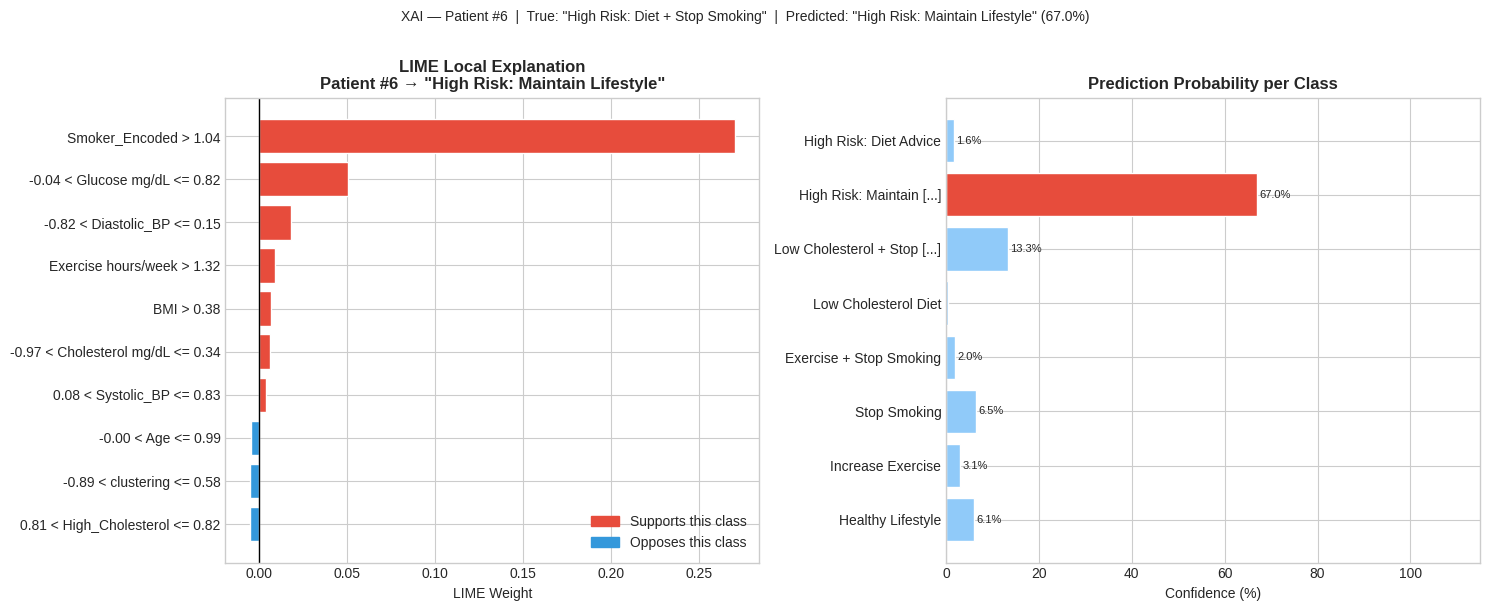

In [63]:
print('='*60)
print('LIME LOCAL EXPLANATION')
print('='*60)

# Initialize lime_explainer here to ensure it's available
# This initialization was originally in cell-api-helpers but is moved here for immediate execution
lime_explainer = LimeTabularExplainer(
    training_data = X_train_final,
    feature_names = FINAL_FEATURES,
    class_names   = [REC_LABELS[i] for i in range(len(REC_LABELS))],
    mode          = 'classification',
    random_state  = RANDOM_STATE
)
print('lime_explainer initialized for local use.')

# Explain a specific test patient
patient_idx  = 5
instance     = X_test_final[patient_idx]
true_label   = y_test.iloc[patient_idx]
pred_label   = xgb_model.predict(instance.reshape(1, -1))[0]
pred_proba   = xgb_model.predict_proba(instance.reshape(1, -1))[0]

lime_exp = lime_explainer.explain_instance(
    data_row         = instance,
    predict_fn       = xgb_model.predict_proba,
    num_features     = 10,
    labels           = [pred_label]
)

print(f'Patient #{patient_idx + 1}')
print(f'  True recommendation:      {REC_LABELS[true_label]}')
print(f'  Predicted recommendation: {REC_LABELS[pred_label]}')
print(f'  Confidence:               {pred_proba[pred_label]*100:.1f}%')
print(f'\nLIME Explanation (top contributing features):')
for feat_expr, weight in lime_exp.as_list(label=pred_label):
    # FIX 5: extract plain feature name and look up clinical value
    plain_name = feat_expr
    for fn in FINAL_FEATURES:
        if fn in feat_expr:
            plain_name = fn
            break
    raw_val = X_test_with_graph.iloc[patient_idx].get(plain_name, '?')
    direction = 'supports' if weight > 0 else 'opposes'
    print(f'  {direction:>8}  |{weight:+.4f}|  {plain_name} = {raw_val}')

# Plot confidence across all classes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
lime_feats, lime_weights = zip(*sorted(lime_exp.as_list(label=pred_label), key=lambda x: x[1]))
colors_lime = ['#e74c3c' if w > 0 else '#3498db' for w in lime_weights]
ax.barh(lime_feats, lime_weights, color=colors_lime, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('LIME Weight')
ax.set_title(f'LIME Local Explanation\nPatient #{patient_idx+1} → "{REC_LABELS[pred_label]}"', fontweight='bold')
red_p  = mpatches.Patch(color='#e74c3c', label='Supports this class')
blue_p = mpatches.Patch(color='#3498db', label='Opposes this class')
ax.legend(handles=[red_p, blue_p])

ax = axes[1]
class_names_s = [textwrap.shorten(REC_LABELS[i], 28) for i in range(len(pred_proba))]
bar_colors2 = ['#e74c3c' if i == pred_label else '#90CAF9' for i in range(len(pred_proba))]
bars = ax.barh(class_names_s, pred_proba * 100, color=bar_colors2, edgecolor='white')
for bar, v in zip(bars, pred_proba * 100):
    if v > 1: ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlabel('Confidence (%)')
ax.set_title('Prediction Probability per Class', fontweight='bold')
ax.set_xlim(0, 115)

plt.suptitle(f'XAI — Patient #{patient_idx+1}  |  True: "{REC_LABELS[true_label]}"  |  Predicted: "{REC_LABELS[pred_label]}" ({pred_proba[pred_label]*100:.1f}%)',
             y=1.01, fontsize=10)
plt.tight_layout()
plt.savefig('lime_explanation.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Step 21: API Functions, Unit Tests & Process 03 Integration

In [64]:
# ── Exception class ───────────────────────────────────────────────────────────
class InputValidationError(Exception):
    pass

# ── Input validation ──────────────────────────────────────────────────────────
def validate_patient_input(data):
    required = ['Age','Gender','Height_cm','Weight_kg','Blood_Pressure',
                'Cholesterol','Glucose','Smoker','Exercise_hours']
    missing = [f for f in required if f not in data]
    if missing:
        raise InputValidationError(f'Missing fields: {missing}')
    ranges = {
        'Age': (18, 120), 'Height_cm': (50, 250), 'Weight_kg': (20, 300),
        'Cholesterol': (100, 600), 'Glucose': (50, 600), 'Exercise_hours': (0, 168)
    }
    for field, (lo, hi) in ranges.items():
        val = data.get(field)
        if val is not None and (val < lo or val > hi):
            raise InputValidationError(f'{field} = {val} is out of range [{lo}, {hi}]')
    return True

# ── Raw input → feature dict ──────────────────────────────────────────────────
def process_raw_input(raw):
    sys_bp, dia_bp = map(int, raw['Blood_Pressure'].split('/'))
    height_m = raw['Height_cm'] / 100
    bmi = raw['Weight_kg'] / (height_m ** 2)
    # FIX 9: assert Gender encoding matches LabelEncoder (Female=0, Male=1 alphabetically)
    assert encoders['Gender'].classes_.tolist() == ['Female', 'Male'], \
        'Gender encoding mismatch — update process_raw_input'
    return {
        'Age':               raw['Age'],
        'Gender_Encoded':    1 if raw['Gender'] == 'Male' else 0,
        'BMI':               round(bmi, 2),
        'Systolic_BP':       sys_bp,
        'Diastolic_BP':      dia_bp,
        'Cholesterol mg/dL': raw['Cholesterol'],
        'Glucose mg/dL':     raw['Glucose'],
        'Smoker_Encoded':    1 if raw['Smoker'] == 'Yes' else 0,
        'High_Cholesterol':  int(raw['Cholesterol'] > THRESHOLDS['cholesterol_high']),
        'High_Glucose':      int(raw['Glucose']     > THRESHOLDS['glucose_high']),
        'Hypertension':      int(sys_bp >= THRESHOLDS['bp_systolic_high'] or
                                 dia_bp >= THRESHOLDS['bp_diastolic_high']),
        'Obesity':           int(bmi >= THRESHOLDS['bmi_obese']),
        'Exercise hours/week': raw['Exercise_hours']
    }

# ── Add graph features for any new patient ────────────────────────────────────
def add_graph_features(base_features):
    bf_arr    = np.array([[base_features[f] for f in FEATURE_COLUMNS]])
    bf_scaled = scaler.transform(bf_arr)
    dists, neighbors = knn_graph.kneighbors(bf_scaled)
    nb_idx  = neighbors[0].flatten()
    weights = 1.0 / (1.0 + dists[0].flatten())
    base_features['degree']     = float(np.average(degree_train[nb_idx],     weights=weights))
    base_features['clustering'] = float(np.average(clustering_train[nb_idx], weights=weights))
    cw = {}
    for ni, w in zip(nb_idx.tolist(), weights.tolist()):
        c = int(community_train[ni])
        cw[c] = cw.get(c, 0) + w
    base_features['community'] = float(max(cw, key=cw.get))
    return base_features

# FIX 5: Create lime_explainer here so it is always available regardless of cell run order
lime_explainer = LimeTabularExplainer(
    training_data = X_train_final,
    feature_names = FINAL_FEATURES,
    class_names   = [REC_LABELS[i] for i in range(len(REC_LABELS))],
    mode          = 'classification',
    random_state  = RANDOM_STATE
)
print('lime_explainer initialised (available globally).')

# FIX 5: Helper to inverse-transform a scaled feature value back to clinical units
def _descale(feature_name, scaled_val):
    """Convert a scaled value back to original units for clinical readability."""
    if feature_name not in FINAL_FEATURES:
        return scaled_val
    idx = FINAL_FEATURES.index(feature_name)
    return round(scaled_val * scaler_graph.scale_[idx] + scaler_graph.mean_[idx], 2)

# ── Dynamic recommendation generator ─────────────────────────────────────────
def generate_recommendations(patient_features, explain=True):
    input_df     = pd.DataFrame([patient_features])[FINAL_FEATURES]
    input_scaled = scaler_graph.transform(input_df)

    risk_prob = xgb_risk.predict_proba(input_scaled)[0][1]
    urgency   = ('immediately'   if risk_prob > 0.7 else
                 'soon'          if risk_prob > 0.3 else
                 'during your next routine checkup')

    # Multi-label recommendation predictions
    rec_probs = {}
    for cat, model in rec_models.items():
        if model is not None:
            rec_probs[cat] = model.predict_proba(input_scaled)[0][1]

    recommendations = []
    for cat, prob in rec_probs.items():
        if prob > 0.5:
            tmpl = REC_TEMPLATES.get(cat, {})
            if tmpl:
                action    = tmpl['action'].format(
                    urgency     = urgency,
                    cholesterol = patient_features.get('Cholesterol mg/dL', '?'),
                    exercise    = patient_features.get('Exercise hours/week', '?'),
                    bp_sys      = patient_features.get('Systolic_BP', '?'),
                    bp_dia      = patient_features.get('Diastolic_BP', '?')
                )
                rationale = tmpl['rationale'].format(
                    cholesterol = patient_features.get('Cholesterol mg/dL', '?'),
                    exercise    = patient_features.get('Exercise hours/week', '?'),
                    bp_sys      = patient_features.get('Systolic_BP', '?'),
                    bp_dia      = patient_features.get('Diastolic_BP', '?')
                )
                recommendations.append({
                    'category':    cat.replace('_', ' '),
                    'priority':    ('High'   if cat in ['High_Risk', 'Smoking_Cessation'] else
                                   'Medium' if cat in ['Diet_Cholesterol', 'BP_Control']  else
                                   'Low'),
                    'action':      action,
                    'rationale':   rationale,
                    'probability': round(prob, 3)
                })

    if not recommendations:
        recommendations.append({
            'category':  'General',
            'priority':  'Low',
            'probability': 0,
            'action':    'Consult your healthcare provider for personalised advice.',
            'rationale': 'No specific recommendation categories triggered.'
        })

    shap_top_factors = []
    lime_top_factors = []

    if explain:
        # ── SHAP: use xgb_risk (binary) so direction is clinically correct ───
        risk_shap_explainer = shap.TreeExplainer(xgb_risk)
        sv = risk_shap_explainer.shap_values(input_scaled)
        if isinstance(sv, list):
            vals = sv[1][0]
        elif sv.ndim == 3:
            vals = sv[0, :, 1]
        else:
            vals = sv[0]

        for i in np.argsort(np.abs(vals))[::-1][:5]:
            shap_top_factors.append({
                'feature':   FINAL_FEATURES[i],
                'impact':    round(float(vals[i]), 4),
                'direction': 'increases risk' if vals[i] > 0 else 'decreases risk',
                'value':     patient_features.get(FINAL_FEATURES[i], 'N/A')
            })

        # ── LIME: local explanation — FIX 5: parse feature name to show clinical value ────
        lime_exp_local = lime_explainer.explain_instance(
            data_row     = input_scaled[0],
            predict_fn   = xgb_risk.predict_proba,
            num_features = 8,
            labels       = (1,)
        )
        for feat_expr, weight in sorted(lime_exp_local.as_list(label=1),
                                        key=lambda x: abs(x[1]), reverse=True)[:5]:
            # FIX 5: extract plain feature name from LIME's range expression
            # e.g. 'Cholesterol mg/dL > 0.69' → 'Cholesterol mg/dL'
            plain_name = feat_expr
            for fn in FINAL_FEATURES:
                if fn in feat_expr:
                    plain_name = fn
                    break
            clinical_val = patient_features.get(plain_name, 'N/A')
            lime_top_factors.append({
                'feature':   f'{plain_name} = {clinical_val}',   # FIX 5: clinical units
                'impact':    round(weight, 4),
                'direction': 'increases risk' if weight > 0 else 'decreases risk'
            })

    return {
        'success':   True,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'risk_assessment': {
            'risk_probability': round(risk_prob, 4),
            'risk_class':       'HIGH_RISK' if risk_prob >= 0.5 else 'LOW_RISK',
            'risk_percentage':  round(risk_prob * 100, 2)
        },
        'recommendations':  recommendations,
        'shap_top_factors': shap_top_factors,
        'lime_top_factors': lime_top_factors
    }

# ── Main API entry point ──────────────────────────────────────────────────────
def api_get_recommendations(patient_raw):
    try:
        validate_patient_input(patient_raw)
        features = process_raw_input(patient_raw)
        features = add_graph_features(features)
        return generate_recommendations(features, explain=True)
    except InputValidationError as e:
        return {'success': False, 'error': str(e)}
    except Exception as e:
        return {'success': False, 'error': f'System error: {e}'}

# ── Process 03 integration ────────────────────────────────────────────────────
def integrate_with_process03(process03_output, patient_raw):
    base_result = api_get_recommendations(patient_raw)
    if not base_result['success']:
        return base_result
    blockage = process03_output.get('blockage_percentage', 0)
    ecg_rec  = []
    if blockage > 60:
        ecg_rec.append({
            'category':  'Critical',
            'priority':  'Urgent',
            'action':    'Immediate consultation with cardiologist required.',
            'rationale': f'Significant blockage detected ({blockage}%).',
            'source':    'ECG/Angiogram (Process 03)'
        })
    elif blockage > 40:
        ecg_rec.append({
            'category':  'Monitoring',
            'priority':  'High',
            'action':    'Regular monitoring and follow-up recommended.',
            'rationale': f'Moderate blockage detected ({blockage}%).',
            'source':    'ECG/Angiogram (Process 03)'
        })
    base_result['recommendations'].extend(ecg_rec)
    base_result['ecg_findings'] = process03_output
    return base_result

print('API functions ready.')


lime_explainer initialised (available globally).
API functions ready.


In [65]:
# ── Unit Tests ────────────────────────────────────────────────────────────────
def test_input_validation():
    valid = {'Age':55,'Gender':'Male','Height_cm':175,'Weight_kg':80,
             'Blood_Pressure':'140/90','Cholesterol':220,'Glucose':110,
             'Smoker':'Yes','Exercise_hours':1}
    assert validate_patient_input(valid) is True

    inv = valid.copy(); del inv['Age']
    try:
        validate_patient_input(inv); assert False
    except InputValidationError:
        pass

    inv2 = valid.copy(); inv2['Age'] = 200
    try:
        validate_patient_input(inv2); assert False
    except InputValidationError:
        pass
    print('  Input validation tests passed.')

def test_process_raw_input():
    raw = {'Age':55,'Gender':'Male','Height_cm':175,'Weight_kg':80,
           'Blood_Pressure':'140/90','Cholesterol':220,'Glucose':110,
           'Smoker':'Yes','Exercise_hours':1}
    proc = process_raw_input(raw)
    assert proc['High_Cholesterol'] == 1
    assert proc['Hypertension'] == 1
    assert 'BMI' in proc
    print('  process_raw_input tests passed.')

def test_api_valid():
    result = api_get_recommendations({
        'Age':42,'Gender':'Male','Height_cm':178,'Weight_kg':75,
        'Blood_Pressure':'118/76','Cholesterol':180,'Glucose':92,
        'Smoker':'No','Exercise_hours':4
    })
    if result is None or not result.get('success'):
        print(f'  API call failed: {result}')
    assert result['success'] is True
    assert 'risk_assessment'  in result
    assert 'recommendations'  in result
    assert 'shap_top_factors' in result
    assert 'lime_top_factors' in result
    print('  API valid-input test passed.')

def test_api_invalid():
    result = api_get_recommendations({'Age': 999})
    assert result['success'] is False
    print('  API invalid-input test passed.')

def test_shap_direction():
    # High-risk patient should have more 'increases risk' SHAP factors
    result = api_get_recommendations({
        'Age':60,'Gender':'Male','Height_cm':170,'Weight_kg':90,
        'Blood_Pressure':'160/100','Cholesterol':260,'Glucose':150,
        'Smoker':'Yes','Exercise_hours':0.5
    })
    assert result['success'] is True
    assert result['risk_assessment']['risk_class'] == 'HIGH_RISK'
    increases = sum(1 for f in result['shap_top_factors'] if f['direction'] == 'increases risk')
    assert increases > 0, 'High-risk patient should have at least one risk-increasing SHAP factor'
    print('  SHAP direction test passed.')

def test_lime_present():
    result = api_get_recommendations({
        'Age':42,'Gender':'Male','Height_cm':178,'Weight_kg':75,
        'Blood_Pressure':'118/76','Cholesterol':180,'Glucose':92,
        'Smoker':'No','Exercise_hours':4
    })
    assert result['success'] is True
    assert len(result['lime_top_factors']) > 0, 'LIME factors should not be empty'
    print('  LIME presence test passed.')

print('Running unit tests...')
test_input_validation()
test_process_raw_input()
test_api_valid()
test_api_invalid()
test_shap_direction()
test_lime_present()
print('\nAll unit tests passed!')

Running unit tests...
  Input validation tests passed.
  process_raw_input tests passed.
  API valid-input test passed.
  API invalid-input test passed.
  SHAP direction test passed.
  LIME presence test passed.

All unit tests passed!


In [66]:
# ── Test API with 3 patient profiles ─────────────────────────────────────────
test_cases = [
    {'name': 'Healthy Patient',
     'data': {'Age':42,'Gender':'Male','Height_cm':178,'Weight_kg':75,
              'Blood_Pressure':'118/76','Cholesterol':180,'Glucose':92,
              'Smoker':'No','Exercise_hours':4}},
    {'name': 'High-Risk Patient',
     'data': {'Age':60,'Gender':'Male','Height_cm':170,'Weight_kg':90,
              'Blood_Pressure':'160/100','Cholesterol':260,'Glucose':150,
              'Smoker':'Yes','Exercise_hours':0.5}},
    {'name': 'Borderline Patient',
     'data': {'Age':55,'Gender':'Female','Height_cm':165,'Weight_kg':80,
              'Blood_Pressure':'135/88','Cholesterol':205,'Glucose':102,
              'Smoker':'No','Exercise_hours':2}},
]

for case in test_cases:
    print('\n' + '='*60)
    print(f'TEST CASE: {case["name"]}')
    print('='*60)
    result = api_get_recommendations(case['data'])
    if result['success']:
        ra = result['risk_assessment']
        print(f'  Risk: {ra["risk_class"]} ({ra["risk_percentage"]:.1f}%)')

        print('\n  Recommendations:')
        for rec in result['recommendations']:
            print(f'    [{rec["priority"]}] {rec["action"]}')
            print(f'           Rationale: {rec["rationale"]}')

        print('\n  SHAP Factors (why this risk level — across similar patients):')
        for f in result['shap_top_factors'][:3]:
            arrow = '↑' if 'increases' in f['direction'] else '↓'
            print(f'    {arrow} {f["feature"]} = {f["value"]}  →  {f["direction"]}  (impact {f["impact"]:+.4f})')

        print('\n  LIME Factors (why this recommendation for THIS patient):')
        for f in result['lime_top_factors'][:3]:
            arrow = '↑' if 'increases' in f['direction'] else '↓'
            print(f'    {arrow} {f["feature"]}  →  {f["direction"]}  (impact {f["impact"]:+.4f})')
    else:
        print(f'  Error: {result["error"]}')

# ── Process 03 integration test ───────────────────────────────────────────────
print('\n' + '='*60)
print('PROCESS 03 INTEGRATION TEST')
print('='*60)
p03_output = {'patient_id': 1, 'risk_level': 'High', 'blockage_percentage': 75, 'severity': 'Critical'}
p03_result = integrate_with_process03(p03_output, test_cases[1]['data'])
if p03_result['success']:
    ra = p03_result['risk_assessment']
    print(f'  Risk: {ra["risk_class"]} ({ra["risk_percentage"]:.1f}%)')

    print('\n  Integrated Recommendations:')
    for rec in p03_result['recommendations']:
        src = rec.get('source', 'Clinical Model')
        print(f'    [{rec["priority"]}] ({src}) {rec["action"]}')

    print('\n  SHAP Factors:')
    for f in p03_result['shap_top_factors'][:3]:
        arrow = '↑' if 'increases' in f['direction'] else '↓'
        print(f'    {arrow} {f["feature"]} = {f["value"]}  →  {f["direction"]}  (impact {f["impact"]:+.4f})')

    print('\n  LIME Factors:')
    for f in p03_result['lime_top_factors'][:3]:
        arrow = '↑' if 'increases' in f['direction'] else '↓'
        print(f'    {arrow} {f["feature"]}  →  {f["direction"]}  (impact {f["impact"]:+.4f})')

    print(f'\n  ECG Findings: {p03_result["ecg_findings"]}')
else:
    print(f'  Error: {p03_result["error"]}')


TEST CASE: Healthy Patient
  Risk: LOW_RISK (1.3%)

  Recommendations:
    [Low] Maintain a healthy lifestyle and attend regular checkups.
           Rationale: Your risk profile is favorable.
    [Low] Continue with regular health screenings and maintain healthy habits.
           Rationale: No major risk factors detected; focus on prevention.

  SHAP Factors (why this risk level — across similar patients):
    ↓ Cholesterol mg/dL = 180  →  decreases risk  (impact -2.9094)
    ↓ Systolic_BP = 118  →  decreases risk  (impact -1.1274)
    ↑ Glucose mg/dL = 92  →  increases risk  (impact +0.9155)

  LIME Factors (why this recommendation for THIS patient):
    ↓ Cholesterol mg/dL = 180  →  decreases risk  (impact -0.3848)
    ↓ Systolic_BP = 118  →  decreases risk  (impact -0.2198)
    ↓ Age = 42  →  decreases risk  (impact -0.1848)

TEST CASE: High-Risk Patient
  Risk: HIGH_RISK (99.8%)

  Recommendations:
    [High] Seek medical advice immediately for a comprehensive cardiovascular eva

---
## Step 22: Patient Dashboard Report

In [67]:
def print_dashboard_report(result, patient_id='Unknown'):
    ra = result['risk_assessment']
    print('=' * 65)
    print(f'  PATIENT RECOMMENDATION REPORT — {patient_id}')
    print(f'  Generated: {result["timestamp"]}')
    print('=' * 65)
    risk_emoji = '🔴' if ra['risk_class'] == 'HIGH_RISK' else '🟢'
    print(f'  {risk_emoji} Risk Level:  {ra["risk_class"]}  ({ra["risk_percentage"]:.1f}%)')
    print()

    print('  Recommendations:')
    for i, rec in enumerate(result['recommendations'], 1):
        prio_icon = {'Urgent':'🚨','High':'🔶','Medium':'🔷','Low':'🔹'}.get(rec['priority'], '•')
        print(f'  {i}. {prio_icon} [{rec["priority"]}] {rec["action"]}')
        print(f'       → {rec["rationale"]}')
    print()

    print('  SHAP — Key risk drivers (behaviour across similar patients):')
    for f in result.get('shap_top_factors', []):
        arrow = '↑' if 'increases' in f['direction'] else '↓'
        print(f'    {arrow} {f["feature"]} = {f["value"]}')
        print(f'         {f["direction"]}  (impact: {f["impact"]:+.4f})')
    print()

    print('  LIME — Why this recommendation for THIS specific patient:')
    for f in result.get('lime_top_factors', []):
        arrow = '↑' if 'increases' in f['direction'] else '↓'
        print(f'    {arrow} {f["feature"]}')
        print(f'         {f["direction"]}  (impact: {f["impact"]:+.4f})')
    print('=' * 65)


# Generate reports for 3 sample patients from test set
for idx in [0, 10, 25]:
    pat_features = X_test_with_graph.iloc[idx].to_dict()
    result = generate_recommendations(pat_features, explain=True)
    print_dashboard_report(result, patient_id=f'Patient #{idx + 1}')
    print()

  PATIENT RECOMMENDATION REPORT — Patient #1
  Generated: 2026-04-01 13:25:15
  🟢 Risk Level:  LOW_RISK  (0.5%)

  Recommendations:
  1. 🔹 [Low] Maintain a healthy lifestyle and attend regular checkups.
       → Your risk profile is favorable.
  2. 🔹 [Low] Continue with regular health screenings and maintain healthy habits.
       → No major risk factors detected; focus on prevention.

  SHAP — Key risk drivers (behaviour across similar patients):
    ↓ Cholesterol mg/dL = 200.0
         decreases risk  (impact: -2.4492)
    ↓ Glucose mg/dL = 88.0
         decreases risk  (impact: -1.4826)
    ↓ Age = 43.0
         decreases risk  (impact: -1.0273)
    ↓ Exercise hours/week = 2.0
         decreases risk  (impact: -0.2727)
    ↑ Systolic_BP = 122.0
         increases risk  (impact: +0.1643)

  LIME — Why this recommendation for THIS specific patient:
    ↓ Glucose mg/dL = 88.0
         decreases risk  (impact: -0.2438)
    ↑ Systolic_BP = 122.0
         increases risk  (impact: +0.1794)

---
## Step 23: Save All Artifacts

In [68]:
os.makedirs('models', exist_ok=True)

# Models
pickle.dump(xgb_model,       open('models/xgb_rec_label_model.pkl', 'wb'))   # rec_label predictor
pickle.dump(xgb_risk,        open('models/xgb_risk_model.pkl', 'wb'))         # binary risk (Heart Attack)
pickle.dump(rec_models,      open('models/rec_multilabel_models.pkl', 'wb'))  # per-category models

# Preprocessors
pickle.dump(scaler,          open('models/scaler_base.pkl', 'wb'))
pickle.dump(scaler_graph,    open('models/scaler_graph.pkl', 'wb'))
pickle.dump(encoders,        open('models/encoders.pkl', 'wb'))
pickle.dump(mlb,             open('models/mlb.pkl', 'wb'))

# Graph data
pickle.dump(knn_graph,       open('models/knn_graph.pkl', 'wb'))
pickle.dump(degree_train,    open('models/degree_train.pkl', 'wb'))
pickle.dump(clustering_train,open('models/clustering_train.pkl', 'wb'))
pickle.dump(community_train, open('models/community_train.pkl', 'wb'))

# Feature metadata
pickle.dump(FINAL_FEATURES,  open('models/final_features.pkl', 'wb'))
pickle.dump(FEATURE_COLUMNS, open('models/feature_columns.pkl', 'wb'))

# Metrics
metrics_out = {
    'rec_label_model': {
        'test_accuracy':  float(accuracy_score(y_test, y_test_pred)),
        'test_f1_weighted': float(f1_score(y_test, y_test_pred, average='weighted', zero_division=0)),
        'best_params':    grid_search.best_params_
    },
    'risk_model': {
        'test_accuracy': float(accuracy_score(y_ha_test, y_ha_test_pred)),
        'test_f1':       float(f1_score(y_ha_test, y_ha_test_pred, zero_division=0)),
        'test_roc_auc':  float(roc_auc_score(y_ha_test, y_ha_test_prob))
    },
    'rec_category_models': rec_metrics
}
with open('models/metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print('All artifacts saved in models/ folder:')
for fname in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{fname}')
    print(f'  models/{fname}  ({size:,} bytes)')

All artifacts saved in models/ folder:
  models/clustering_train.pkl  (4,480 bytes)
  models/community_train.pkl  (4,480 bytes)
  models/degree_train.pkl  (4,480 bytes)
  models/encoders.pkl  (339 bytes)
  models/feature_columns.pkl  (208 bytes)
  models/final_features.pkl  (242 bytes)
  models/knn_graph.pkl  (65,832 bytes)
  models/metrics.json  (1,122 bytes)
  models/mlb.pkl  (442 bytes)
  models/rec_multilabel_models.pkl  (589,349 bytes)
  models/scaler_base.pkl  (1,041 bytes)
  models/scaler_graph.pkl  (1,147 bytes)
  models/xgb_rec_label_model.pkl  (299,786 bytes)
  models/xgb_risk_model.pkl  (161,059 bytes)
